<a href="https://colab.research.google.com/github/Samuelameningayeh/thesis/blob/main/synthetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import cmdstanpy
# cmdstanpy.install_cmdstan()


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path

from scipy.integrate import odeint
from posterior_plot import plot_posterior_kde_grid

import logging
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.disabled = True

/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Define the SEIR model

$$ 
\begin{aligned}
\frac{dS_p}{dt} &= -\beta_p S_p \frac{I_p}{N_p}\\

\frac{dE_p}{dt} &= \beta_p S_p \frac{I_p}{N_p} - \sigma_p E_p \\

\frac{dI_p}{dt} &= \sigma_p E_p - \gamma_p I_p\\

\frac{dR_p}{dt} &= \gamma_p I_p
\end{aligned}
$$

Where:
- $ S_p, E_p, I_p, R_p $: Susceptible, Exposed, Infectious, and Recovered individuals in patch $ p $.
- $ N_p $: Total population for patch $ p $.
- $ \beta_p $: Transmission rate in patch $ p $.
- $ \sigma_p $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma_p $: Recovery rate (inverse of the infectious period).

In [43]:
# ---- SEIR ODE system --------------------------------------------------------
def seir(state, t, beta, sigma, gamma, N):
    n=len(N)
    S = state[:n]
    E = state[n:2*n]
    I = state[2*n:3*n]
    R = state[3*n:4*n]
    C = state[4*n:]

    dS = np.zeros(n)
    dE = np.zeros(n)
    dI = np.zeros(n)
    dR = np.zeros(n)
    dC = np.zeros(n)
    
    for i in range(n):
        dS[i] = -beta[i] * S[i] * I[i] / N[i]
        dE[i] =  beta[i] * S[i] * I[i] / N[i] - sigma * E[i]
        dI[i] =  sigma * E[i] - gamma * I[i]
        dR[i] =  gamma * I[i]
        dC[i] = sigma * E[i]
    
    return np.concatenate([dS.flatten(), dE.flatten(), dI.flatten(), dR.flatten(), dC.flatten()])


# Define Parameters

In [ ]:
n_regions = 3 
T = 96 #679/7
# Time vector
t = np.linspace(0, T, T)

N = [11.5e6, 4.5e6, 6.8e6]  # Guinea, Liberia, Sierra Leone
## Get the Parameters
beta = np.array([0.25, 0.27, 0.26])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = (1/5)*7             #incubation rate per week
gamma = (1/6.6)*7     # 1/infectious period per week (Ebola: ~7 days)

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported

# Initial conditions
E0 = np.array([10, 10, 10])
I0 = np.array([10, 1, 1])
R0 = np.array([0,0,0])
C0 = np.array([0,0,0])
S0 = np.array([N[0]-E0[0]-I0[0], N[1]-E0[1]-I0[1], N[2]-E0[2]-I0[2]])

# initial_state = [guinea, lib, sir]
y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), C0.flatten()])


# Solve the ODEs

In [45]:
# Simulate SEIR for each region
sol = odeint(seir, y0, t, args=(beta, sigma, gamma, N))

## Get the New Infections and Deaths

In [46]:
n = 3
# Extract and aggregate results
# S = sol[:, :n]
# E = sol[:, n:2*n]
# I = sol[:, 2*n:3*n]
# R = sol[:, 3*n:4*n]
# D = sol[:, 4*n:]

## Total per patch (sum over resident patches i)
S_total = sol[:, :n]
E_total = sol[:, n:2*n]
I_total = sol[:, 2*n:3*n]
R_total = sol[:, 3*n:4*n]
C_total = sol[:, 4*n:]


## get the new infected individuals at each time
Infections = np.zeros([T, n])

for j in range(3):
    ## get new infections
    for i in (range(len(C_total))):

        if (i+1 == len(C_total)):
            new_infections = [0.0,0.0,0.0]
            Infections[i, j] = new_infections[j]
        else:
            new_infections = C_total[i+1] - C_total[i]
            Infections[i+1, j] = new_infections[j]

## Show New infections

In [47]:
Infections[:100]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.69417093e+01, 1.11250589e+01, 1.09764160e+01],
       [2.39989560e+01, 1.34457412e+01, 1.27898913e+01],
       [3.39797210e+01, 2.00660554e+01, 1.84967954e+01],
       [4.81102103e+01, 3.02085293e+01, 2.70066692e+01],
       [6.81164979e+01, 4.54918283e+01, 3.94462840e+01],
       [9.64416115e+01, 6.85073090e+01, 5.76161899e+01],
       [1.36543970e+02, 1.03165026e+02, 8.41548020e+01],
       [1.93319120e+02, 1.55351632e+02, 1.22915586e+02],
       [2.73696289e+02, 2.33927192e+02, 1.79525352e+02],
       [3.87481895e+02, 3.52223077e+02, 2.62199062e+02],
       [5.48551615e+02, 5.30289524e+02, 3.82927691e+02],
       [7.76533787e+02, 7.98261759e+02, 5.59208380e+02],
       [1.09918380e+03, 1.20138660e+03, 8.16560871e+02],
       [1.55572823e+03, 1.80749698e+03, 1.19218086e+03],
       [2.20156370e+03, 2.71805198e+03, 1.74022821e+03],
       [3.11483860e+03, 4.08427781e+03, 2.53944965e+03],
       [4.40562920e+03, 6.13038

## Add Noise

In [48]:
from add_noise import Add_noise

observed_cases = Add_noise(Infections, reporting_rate= reporting_rate, phi=phi, seed=1)
c = pd.DataFrame(observed_cases, columns = ['Guinea', 'Liberia', 'Sierra Leone'])


## Create a dataframe

In [59]:
# Create dataset
data = {
    'time': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'C_Guinea': C_total[:, 0],
    'Guinea_New_case': Infections[:, 0],
    'Guinea_Noise' : c['Guinea'],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'C_Liberia': C_total[:, 1],
    'Liberia_New_case': Infections[:, 1],
    'Liberia_Noise' : c['Liberia'],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'C_SierraLeone': C_total[:, 2],
    'SierraLeone_New_case': Infections[:, 2],
    'SierraLeone_Noise' : c['Sierra Leone'],
}

raw = pd.DataFrame(data)
raw.to_csv('Data/synthetic_dataset_no_coupling.csv', index=False)
raw.head()

,time,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,C_Guinea,Guinea_New_case,Guinea_Noise,S_Liberia,...,C_Liberia,Liberia_New_case,Liberia_Noise,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,C_SierraLeone,SierraLeone_New_case,SierraLeone_Noise
0,2013-12-28,0,1.149998e+07,10.000000,10.000000,0.000000,0.000000,0.000000,0,4.499989e+06,...,0.000000,0.000000,0,6.799989e+06,10.000000,1.000000,0.000000,0.000000,0.000000,0
1,2013-12-29,1,1.149996e+07,14.183939,14.138252,12.803457,16.941709,16.941709,10,4.499980e+06,...,11.125059,11.125059,14,6.799980e+06,7.641850,6.954105,5.022311,10.976416,10.976416,9
2,2013-12-30,2,1.149993e+07,20.083906,20.016560,30.924105,40.940665,23.998956,22,4.499963e+06,...,24.570800,13.445741,9,6.799964e+06,10.765343,10.470425,14.295882,23.766307,12.789891,7
3,2013-12-31,3,1.149989e+07,28.435931,28.340472,56.579914,74.920386,33.979721,33,4.499937e+06,...,44.636856,20.066055,11,6.799941e+06,15.701741,15.311418,27.951685,42.263103,18.496795,11
4,2014-01-01,4,1.149983e+07,40.260923,40.125864,92.904732,123.030596,48.110210,37,4.499898e+06,...,74.845385,30.208529,63,6.799907e+06,22.933287,22.365524,47.904248,69.269772,27.006669,23


# Plot the results

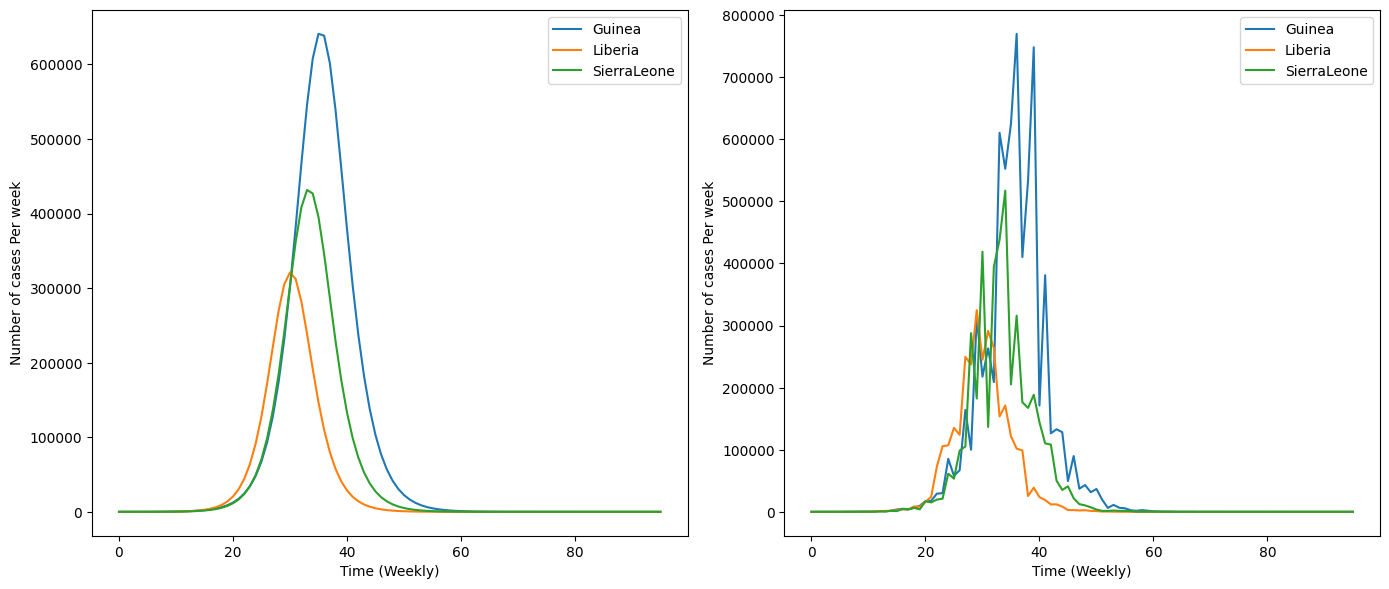

In [60]:
fig, ax = plt.subplots(1,2, figsize = (14, 6))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw[f'{countries[i]}_New_case'])
    ax[0].legend(countries)
    # ax[0].set_title('Number of new infections NO NOISE at time t $[\int_0^T \sigma*$E]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases Per week')

    ax[1].plot(raw[f'{countries[i]}_Noise'])
    ax[1].legend(countries)
    # ax[1].set_title('Number of new infections with NOISE at time t $[\int_0^T \sigma*$E]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')

    # ax[2].plot(raw[f'C_{countries[i]}'])
    # ax[2].legend(countries)
    # ax[2].set_title('Number of Infections at time t [$ \sigma$ * E]')
    # ax[2].set_xlabel('Time (Weekly)')
    # ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.savefig('images/generated_no_coupling.pdf')
plt.show()

In [61]:
# Plot for each country
countries = ['Guinea', 'Liberia', 'SierraLeone']
def plot_SEIR(df, country_name, Death = False, save=False, yscale = False):
    # Extract data for the current country
    S = df[f'S_{country_name}']
    E = df[f'E_{country_name}']
    I = df[f'I_{country_name}']
    R = df[f'R_{country_name}']

    # Create plot
    plt.figure(figsize=(13, 6))
    plt.plot(df['Day'], S, label='Susceptible', color='blue')
    plt.plot(df['Day'], E, label='Exposed', color='orange')
    plt.plot(df['Day'], I, label='Infective', color='red')
    plt.plot(df['Day'], R, label='Removed', color='green')
    if Death:
        D = df[f'D_{country_name}']
        plt.plot(df['Day'], D, label='Death', color='black')

    # Customize the plot
    plt.xlabel('Day')
    plt.ylabel('Number of Individuals')
    plt.title(f'SEIRD Dynamics for {country_name}')
    plt.legend()
    plt.grid(True)
    if yscale:
        plt.yscale('symlog')  # Use symlog scale to handle large ranges
    if save:
        plt.savefig(f'seird_{country_name.lower()}.png')
    plt.show()

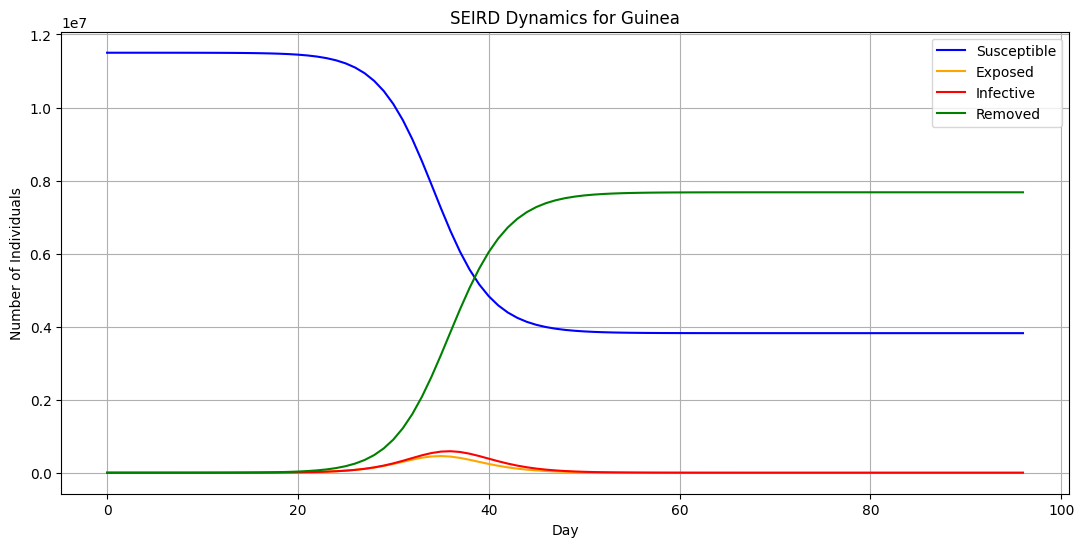

In [62]:
plot_SEIR(raw, 'Guinea')

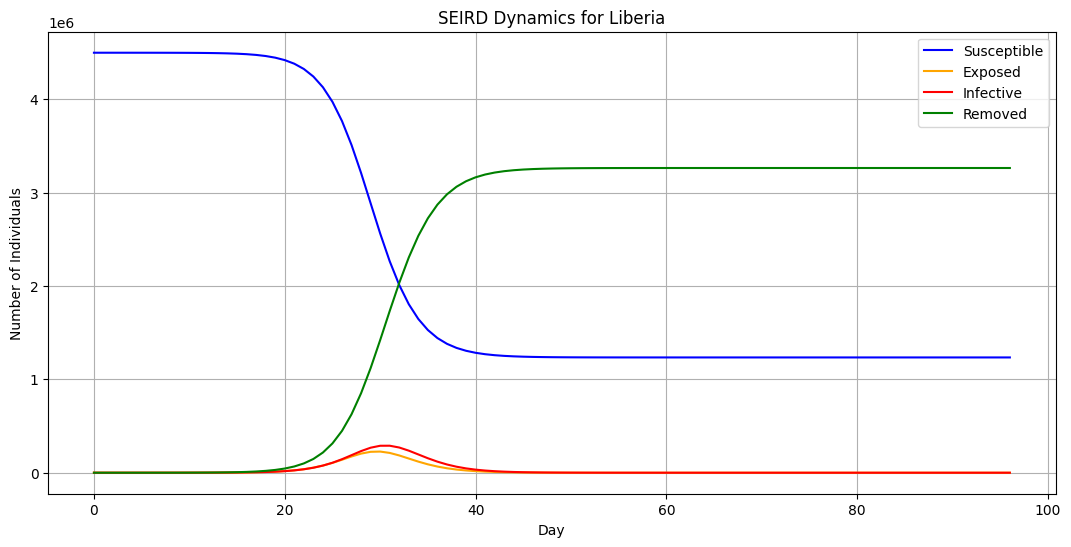

In [63]:
plot_SEIR(raw, 'Liberia')

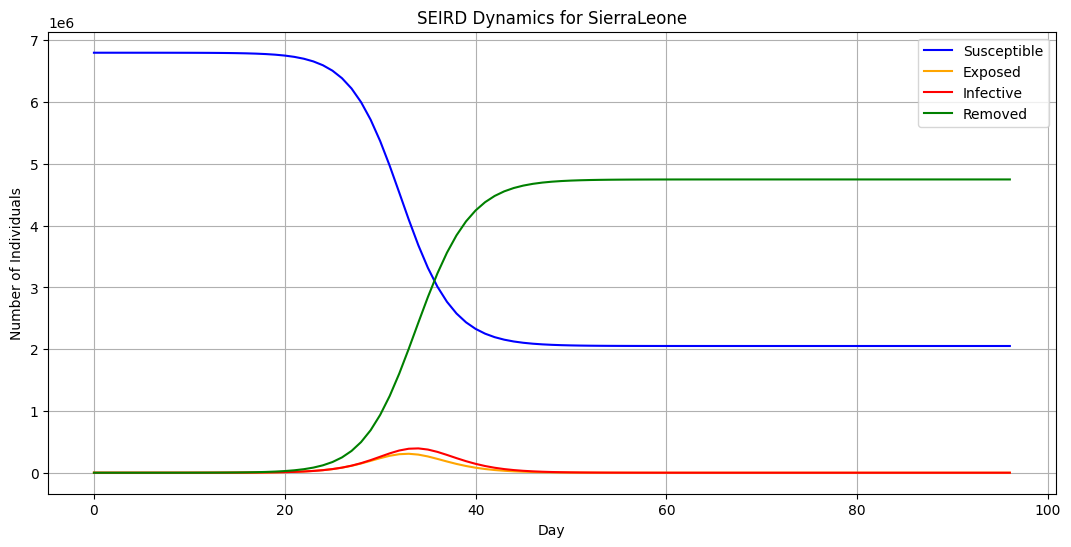

In [64]:
plot_SEIR(raw, 'SierraLeone')

# Create a function to plot Posterior for Parameters

# Fit the Model to daily cases


In [65]:
# # Aggregate cases by country and week
# countries = ['Guinea', 'Liberia', 'Sierra Leone']
# # weekly_cases = df.groupby(['country', pd.Grouper(key='time', freq='W')]).sum().unstack(fill_value=0).T
# weekly_cases1 = raw['Guinea_Noise']
# weekly_cases2 = raw['Liberia_Noise']
# weekly_cases3 = raw['SierraLeone_Noise']

# cases1 = weekly_cases1.values  # Shape: (T, 3)
# cases2 = weekly_cases2.values  # Shape: (T, 3)
# cases3 = weekly_cases3.values  # Shape: (T, 3)

# N = np.array([11.5e6, 4.5e6, 6.8e6])

# beta = np.array([0.25, 0.27, 0.26])*7  # Transmission rate per week (R0 = beta/gamma)
# sigma = (1/5)*7 #incubation rate per week
# gamma = (1/6.6)*7 

# phi = 10           # Negative binomial dispersion parameter
# reporting_rate = 1 

# # Define initial conditions
# i0 = [10, 10, 10]
# e0 = [10, 1, 1]
# s0 = N - i0 - e0
# r0 = [0, 0, 0]
# c0 = [0, 0, 0]
# y1 = [s0[0], e0[0], i0[0], r0[0], c0[0]]
# y2 = [s0[1], e0[1], i0[1], r0[1], c0[1]]
# y3 = [s0[2], e0[2], i0[2], r0[2], c0[2]]


In [66]:

# # Make the data struture
# seir_data1 = {
#     "n_days": len(cases1),
#     "y0": y1,
#     "t0": 0,
#     "t": np.arange(1, len(cases1)+1),
#     "N": int(N[0]),
#     "cases": cases1,
#     'beta_value': beta[0],
#     'sigma_value': sigma,
#     'gamma_value': gamma,
#     "reporting_rate": reporting_rate
# }

# seir_data2 = {
#     "n_days": len(cases2),
#     "y0": y2,
#     "t0": 0,
#     "t": np.arange(1, len(cases2)+1),
#     "N": int(N[1]),
#     "cases": cases2,
#     'beta_value': beta[1],
#     'sigma_value': sigma,
#     'gamma_value': gamma,
#     "reporting_rate": reporting_rate
# }
# seir_data3 = {
#     "n_days": len(cases3),
#     "y0": y3,
#     "t0": 0,
#     "t": np.arange(1, len(cases3)+1),
#     "N": int(N[2]),
#     "cases": cases3,
#     'beta_value': beta[2],
#     'sigma_value': sigma,
#     'gamma_value': gamma,
#     "reporting_rate": reporting_rate
# }

# seir_incidence_model1 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
# seir_incidence_model2 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
# seir_incidence_model3 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')

In [73]:
%run fit_single.py

Compiling stan file for Guinea
Done compiling
Running model fit for Guinea at time 20250607_113432...


chain 1 |          | 00:00 Status




chain 1 |▌         | 00:07 Status


chain 1 |█▏        | 01:25 Iteration:    1 / 1500 [  0%]  (Warmup)


chain 1 |█▊        | 02:51 Iteration:  100 / 1500 [  6%]  (Warmup)



chain 1 |██▎       | 04:00 Iteration:  200 / 1500 [ 13%]  (Warmup)

chain 1 |██▉       | 05:04 Iteration:  300 / 1500 [ 20%]  (Warmup)




chain 1 |████      | 06:16 Iteration:  500 / 1500 [ 33%]  (Warmup)



chain 1 |████▋     | 07:09 Iteration:  501 / 1500 [ 33%]  (Sampling)


chain 1 |█████▎    | 08:20 Iteration:  600 / 1500 [ 40%]  (Sampling)


chain 1 |█████▉    | 09:24 Iteration:  700 / 1500 [ 46%]  (Sampling)
chain 1 |██████▍   | 10:31 Iteration:  800 / 1500 [ 53%]  (Sampling)


chain 1 |███████   | 11:23 Iteration:  900 / 1500 [ 60%]  (Sampling)


chain 1 |███████▋  | 12:51 Iteration: 1000 / 1500 [ 66%]  (Sampling)


chain 1 |████████▏ | 13:46 Iteration: 1100 / 1500 [ 73%]  (Sampling)




chain 1 |████████▊ | 14:50 Iteration: 1200 / 1500 [ 80%]  (Sampling)
chain 1 |███


Fit for Guinea saved to: outputs/guinea_20250607_113432
Compiling stan file for Liberia
Done compiling
Running model fit for Liberia at time 20250607_115333...


chain 1 |          | 00:00 Status





chain 1 |██████████| 00:49 Iteration: 1400 / 1500 [ 93%]  (Sampling)














































chain 1 |██████████| 13:35 Sampling completed                       
chain 2 |██████████| 13:35 Sampling completed                       
chain 3 |██████████| 13:35 Sampling completed                       
chain 4 |██████████| 13:35 Sampling completed                       


Fit for Liberia saved to: outputs/liberia_20250607_115333
Compiling stan file for SierraLeone
Done compiling
Running model fit for SierraLeone at time 20250607_120708...


chain 1 |          | 00:00 Status










































chain 1 |█▊        | 11:49 Iteration:  100 / 1500 [  6%]  (Warmup)





chain 1 |██▎       | 13:08 Iteration:  200 / 1500 [ 13%]  (Warmup)


chain 1 |██████████| 31:54 Sampling completed                       
chain 2 |██████████| 31:54 Sampling completed                       
chain 3 |██████████| 31:54 Sampling completed                       
chain 4 |██████████| 31:54 Sampling completed                       


Fit for SierraLeone saved to: outputs/sierraleone_20250607_120708
Fits for all countries completed. Check 'output/' directory.


In [74]:
from cmdstanpy import from_csv

# Load Guinea fit
fit1 = from_csv('output/guinea_20250607_103939/fit_*_*.csv')
print("Guinea fit loaded")

# Load Liberia fit
fit2 = from_csv('output/liberia_20250607_103939/fit_*_*.csv')
print("Liberia fit loaded")

# Load Sierra Leone fit
fit3 = from_csv('output/sierra_leone_20250607_103939/fit_*_*.csv')
print("Sierra Leone fit loaded")

ValueError: Invalid path specification, output/guinea_20250607_103939/fit_*_*.csv  unknown directory: output/guinea_20250607_103939

In [71]:
# fit2 = seir_incidence_model2.sample(data = seir_data2,
#                                    iter_sampling = 1000,
#                                 #    parallel_chains=True,
#                                    chains = 4,
#                                    seed = 2)

In [72]:
# fit3 = seir_incidence_model3.sample(data = seir_data3,
#                                    iter_sampling = 1000,
#                                 #    parallel_chains=True,
#                                    chains = 4,
#                                    seed = 0)

In [22]:
print(fit3.diagnose())

Checking sampler transitions treedepth.
1000 of 1000 (100.00%) transitions hit the maximum treedepth limit of 10, or 2^10 leapfrog steps.
Trajectories that are prematurely terminated due to this limit will result in slow exploration.
For optimal performance, increase this limit.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.00, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  y[24,2], y[25,2], y[26,2], y[27,2], y[28,2], y[29,2], y[30,2], y[32,2], y[33,2], y[35,2], y[36,2], y[37,2], y[38,2], y[39,2], y[40,2], y[41,2], y[43,2], y[44,2], y[45,2], y[46,2], y[47,2], y[49,2], y[50,2], y[51,2], y[52,2], y[53,2], y[54,2], y

In [23]:
fit1_summary = fit1.summary()
fit1_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,1.302190,0.005119,0.219251,0.208624,0.982363,1.283440,1.692700,1969.04,1578.72,1.00114
beta,1.923750,0.006550,0.232249,0.235830,1.587230,1.902200,2.333050,1229.43,1706.25,1.00276
gamma,1.156780,0.004947,0.178307,0.176837,0.891265,1.141450,1.465730,1268.90,1607.37,1.00267
recovery_time,0.884972,0.003867,0.136202,0.136016,0.682255,0.876078,1.122000,1268.94,1607.37,1.00267
incubation_period,0.789153,0.002900,0.129900,0.126173,0.590774,0.779155,1.017950,1969.02,1578.72,1.00132
R0,1.673650,0.002428,0.100241,0.097066,1.529360,1.662520,1.851680,1818.69,1777.88,1.00178
phi,6.355410,0.026423,1.137540,1.078830,4.598580,6.280790,8.321580,1866.12,1708.80,1.00011
phi_inv,0.162530,0.000711,0.030002,0.027363,0.120169,0.159216,0.217458,1866.13,1708.80,1.00011


In [24]:
fit2_summary = fit2.summary()
fit2_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,1.261080,0.092209,0.206161,0.296550,0.932940,1.255880,1.493120,12.61050,2000.0,1.23114
beta,1.607180,0.474022,0.689163,0.290048,0.452273,1.897040,2.321820,6.92884,2000.0,1.56472
gamma,1.561970,0.586766,0.840260,0.258306,0.861069,1.138890,2.997160,6.79525,2000.0,1.59629
recovery_time,0.790707,0.189647,0.290210,0.208367,0.333649,0.878043,1.161350,6.79189,2000.0,1.59671
incubation_period,0.815555,0.059739,0.140759,0.173675,0.669740,0.796255,1.071880,12.40250,2000.0,1.23535
R0,1.428460,0.522325,0.747340,0.201537,0.150902,1.783850,2.071890,6.78986,2000.0,1.59149
phi,4.991820,1.356910,2.117280,1.657170,1.741770,5.530580,7.836980,6.71033,2000.0,1.59377
phi_inv,0.271274,0.123762,0.176991,0.050478,0.127600,0.180813,0.574129,6.71037,2000.0,1.59381


In [25]:
fit3_summary = fit3.summary()
fit3_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,1.328730,NaN,0.457767,0.190314,0.893130,1.116760,2.09892,NaN,NaN,NaN
beta,1.391150,NaN,0.724184,0.237112,0.159631,1.717410,2.05771,NaN,NaN,NaN
gamma,1.031770,NaN,0.108262,0.085418,0.859302,1.038720,1.22590,NaN,NaN,NaN
recovery_time,0.979843,NaN,0.102931,0.080395,0.815723,0.962724,1.16373,NaN,NaN,NaN
incubation_period,0.828247,NaN,0.224435,0.161789,0.476435,0.895447,1.11965,NaN,NaN,NaN
R0,1.357330,NaN,0.699493,0.131848,0.153681,1.713440,1.90705,NaN,NaN,NaN
phi,7.174810,NaN,4.248020,2.423720,0.266865,8.657450,12.13290,NaN,NaN,NaN
phi_inv,1.018480,NaN,1.575720,0.030418,0.082421,0.115507,3.74721,NaN,NaN,NaN


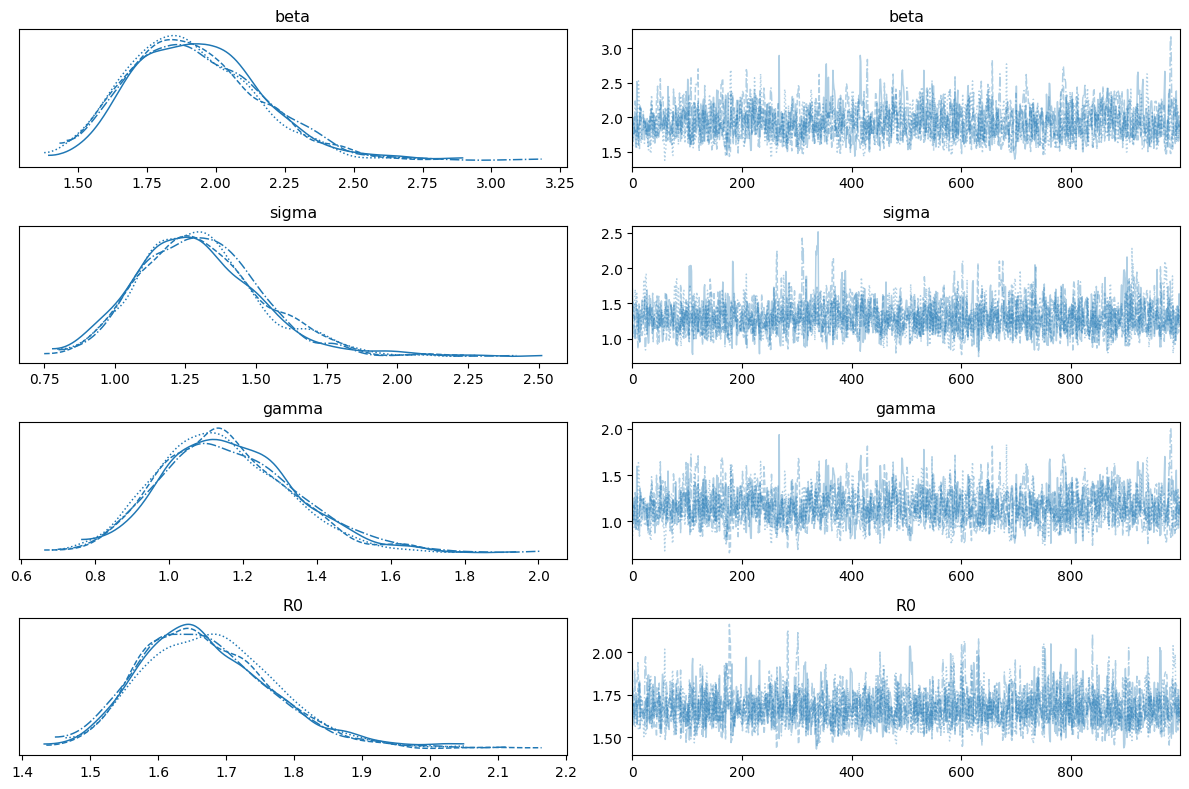

In [26]:
## trace plots
az.plot_trace(fit1, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

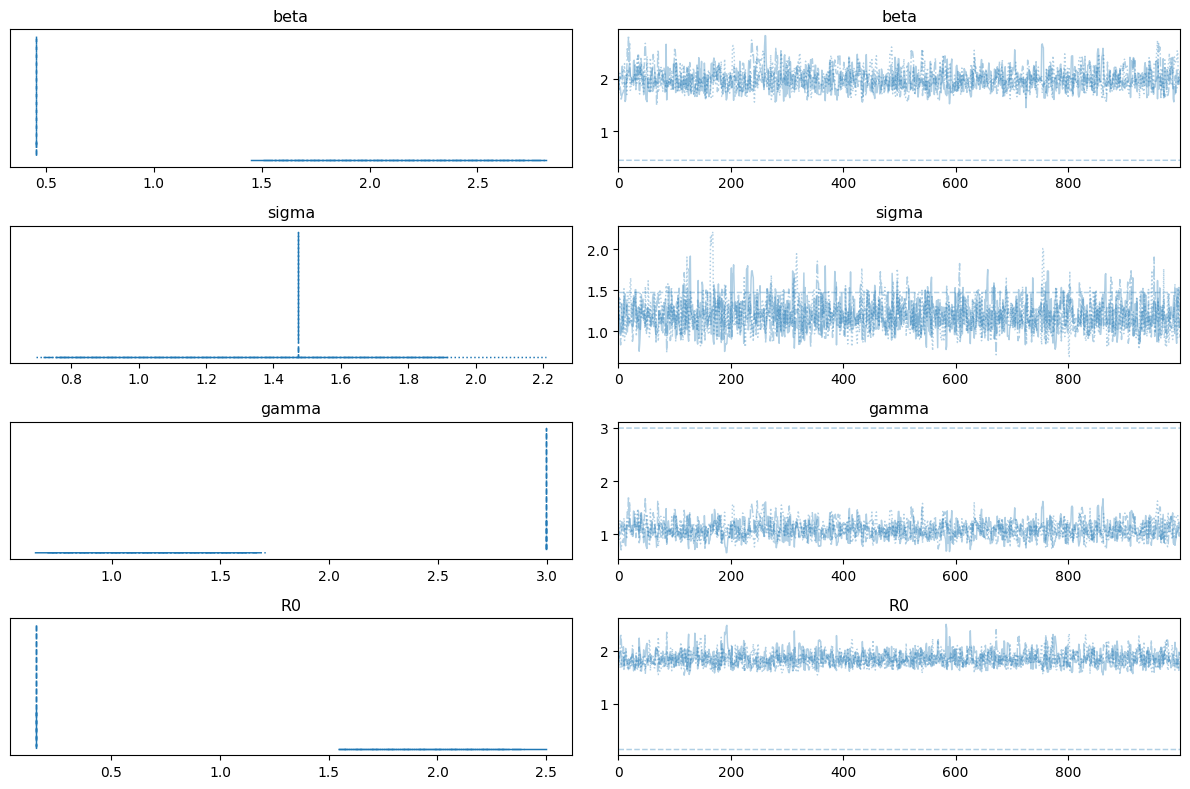

In [27]:
az.plot_trace(fit2, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to 

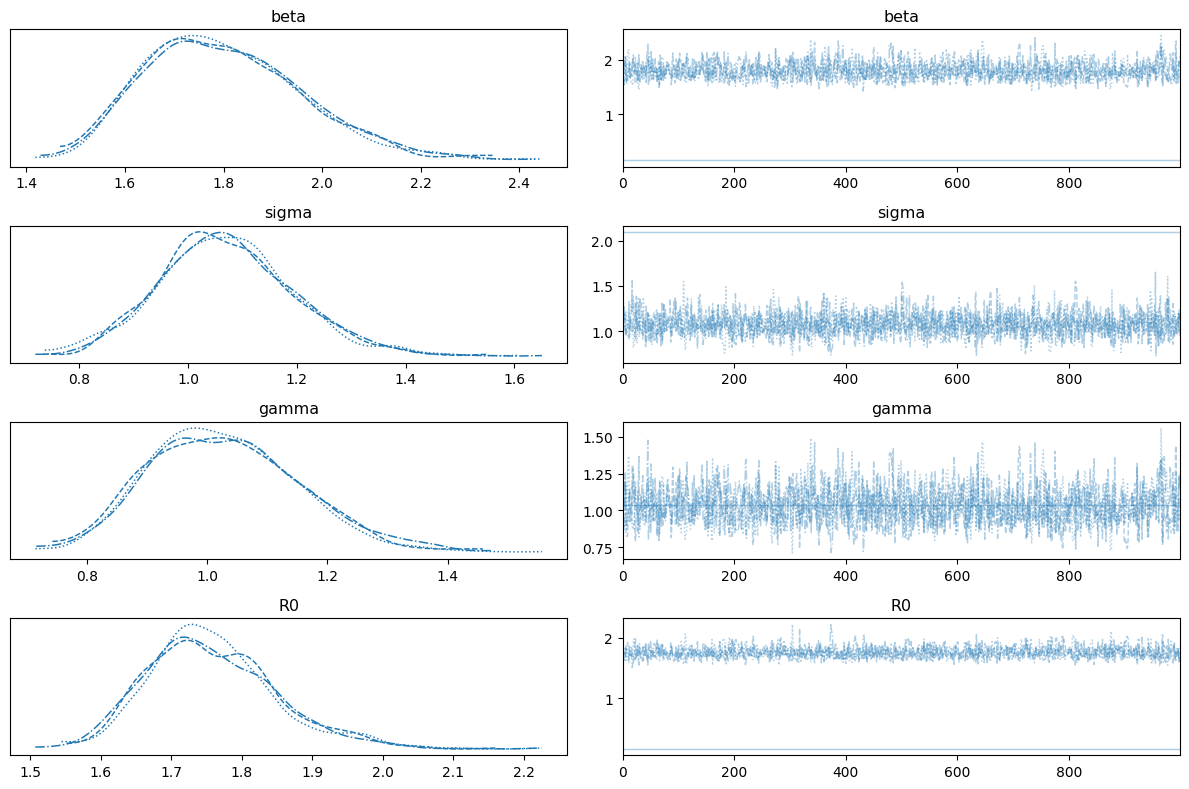

In [28]:
az.plot_trace(fit3, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

In [ ]:
# Extract posterior samples
post_guinea = fit1.draws_pd()
post_liberia = fit2.draws_pd()
post_sierra = fit3.draws_pd()

# ## save the posterior samples
# post_guinea.to_csv('./Data/posterior_samples_guinea.csv', index=False)
# post_liberia.to_csv('./Data/posterior_samples_liberia.csv', index=False)
# post_sierra.to_csv('./Data/posterior_samples_sierra.csv', index=False)

# Posterior Predictive Checks

In [30]:
fit1_summary.filter(like="pred_incidence", axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
pred_incidence[1],16.59500,0.129185,7.957190,7.4130,6.0,15.0,32.00,3862.82,3955.72,1.00016
pred_incidence[2],23.28900,0.172256,10.721500,10.3782,9.0,22.0,43.00,3910.84,3833.26,1.00086
pred_incidence[3],33.51250,0.240548,14.552000,13.3434,13.0,32.0,61.00,3775.80,3830.32,1.00112
pred_incidence[4],47.04950,0.349578,20.677300,19.2738,19.0,44.0,84.05,3615.36,3892.30,1.00043
pred_incidence[5],68.36000,0.482790,29.019400,26.6868,28.0,65.0,122.00,3603.69,3748.39,1.00013
...,...,...,...,...,...,...,...,...,...,...
pred_incidence[92],0.02925,NaN,0.172922,0.0000,0.0,0.0,0.00,NaN,NaN,NaN
pred_incidence[93],0.02600,NaN,0.160719,0.0000,0.0,0.0,0.00,NaN,NaN,NaN
pred_incidence[94],0.02075,NaN,0.144307,0.0000,0.0,0.0,0.00,NaN,NaN,NaN
pred_incidence[95],0.01500,NaN,0.123608,0.0000,0.0,0.0,0.00,NaN,NaN,NaN


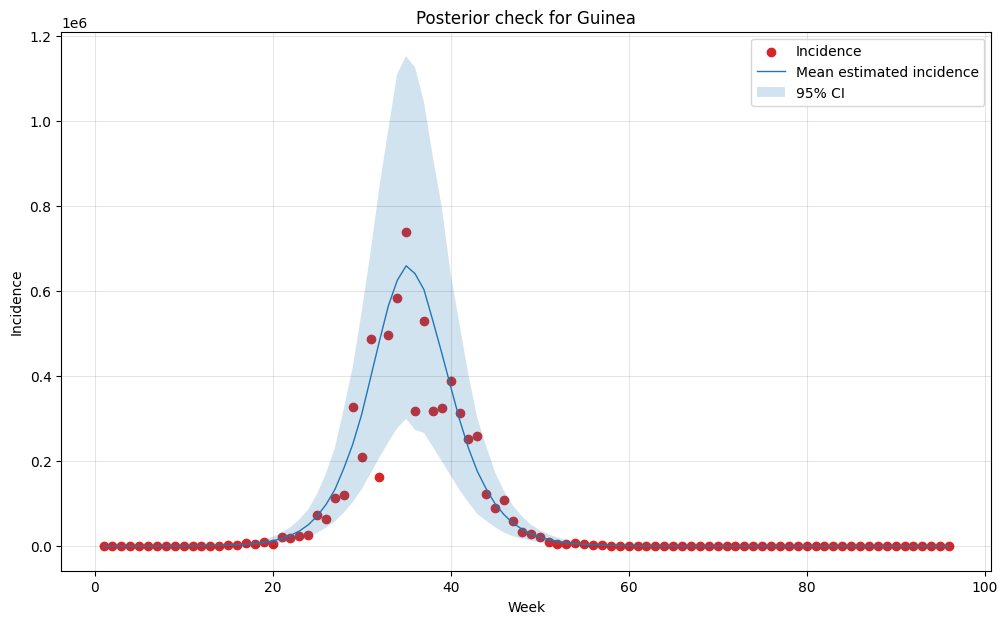

In [31]:
post_pred1 = pd.DataFrame(fit1_summary.filter(like="pred_incidence", axis=0))
post_pred1["t"] = range(1, T+1)
post_pred1["incidence"] = list(cases1)
post_pred1 = post_pred1.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Guinea')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred1.index, y = post_pred1.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred1.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred1.index, y1 = post_pred1['5%'], y2 = post_pred1['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

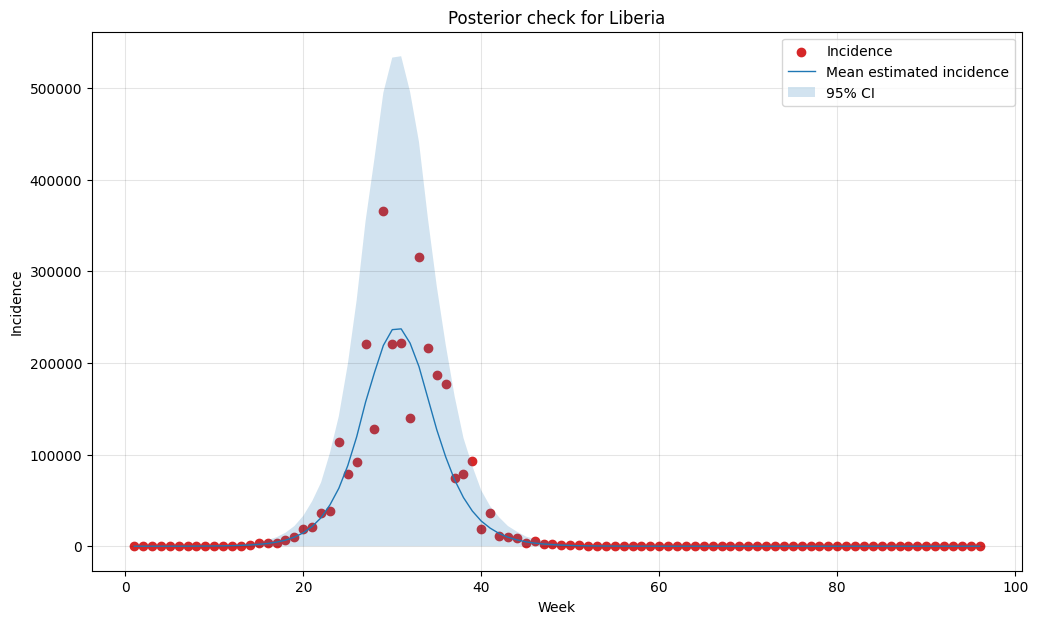

In [32]:
post_pred2 = pd.DataFrame(fit2_summary.filter(like="pred_incidence", axis=0))
post_pred2["t"] = range(1, T+1)
post_pred2["incidence"] = list(cases2)
post_pred2 = post_pred2.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Liberia')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred2.index, y = post_pred2.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred2.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred2.index, y1 = post_pred2['5%'], y2 = post_pred2['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

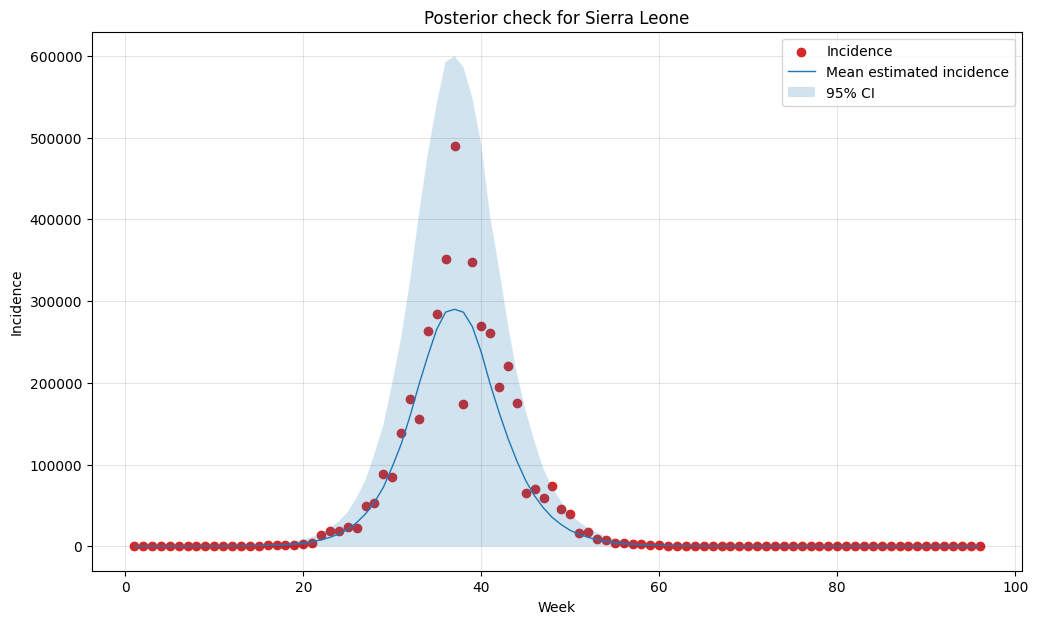

In [33]:
post_pred3 = pd.DataFrame(fit3_summary.filter(like="pred_incidence", axis=0))
post_pred3["t"] = range(1, T+1)
post_pred3["incidence"] = list(cases3)
post_pred3 = post_pred3.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Sierra Leone')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred3.index, y = post_pred3.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred3.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred3.index, y1 = post_pred3['5%'], y2 = post_pred3['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

In [34]:
# Assuming `fit` is your CmdStanMCMC object from fitting the model
parameters1 = ["beta", "sigma", "recovery_time", "gamma", "incubation_period", "R0","phi"]

beta = np.array([0.25, 0.27, 0.26])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = np.array([1/4, 1/5, 1/6])*7 #incubation rate per week
gamma = np.array([1/6.3, 1/6.6, 1/6.6])*7  

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported
r = beta/(gamma)
rec = 1.0/gamma
incu = 1.0 / sigma

t1 = {'beta':beta[0],'sigma': sigma[0], 'gamma': gamma[0], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[0], 'recovery_time':rec[0],
    'incubation_period': incu[0]}

t2 = {'beta':beta[1],'sigma': sigma[1], 'gamma': gamma[1], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[1], 'recovery_time':rec[1],
    'incubation_period': incu[1]}

t3 = {'beta':beta[2],'sigma': sigma[2], 'gamma': gamma[2], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[2], 'recovery_time':rec[2],
    'incubation_period': incu[2]}

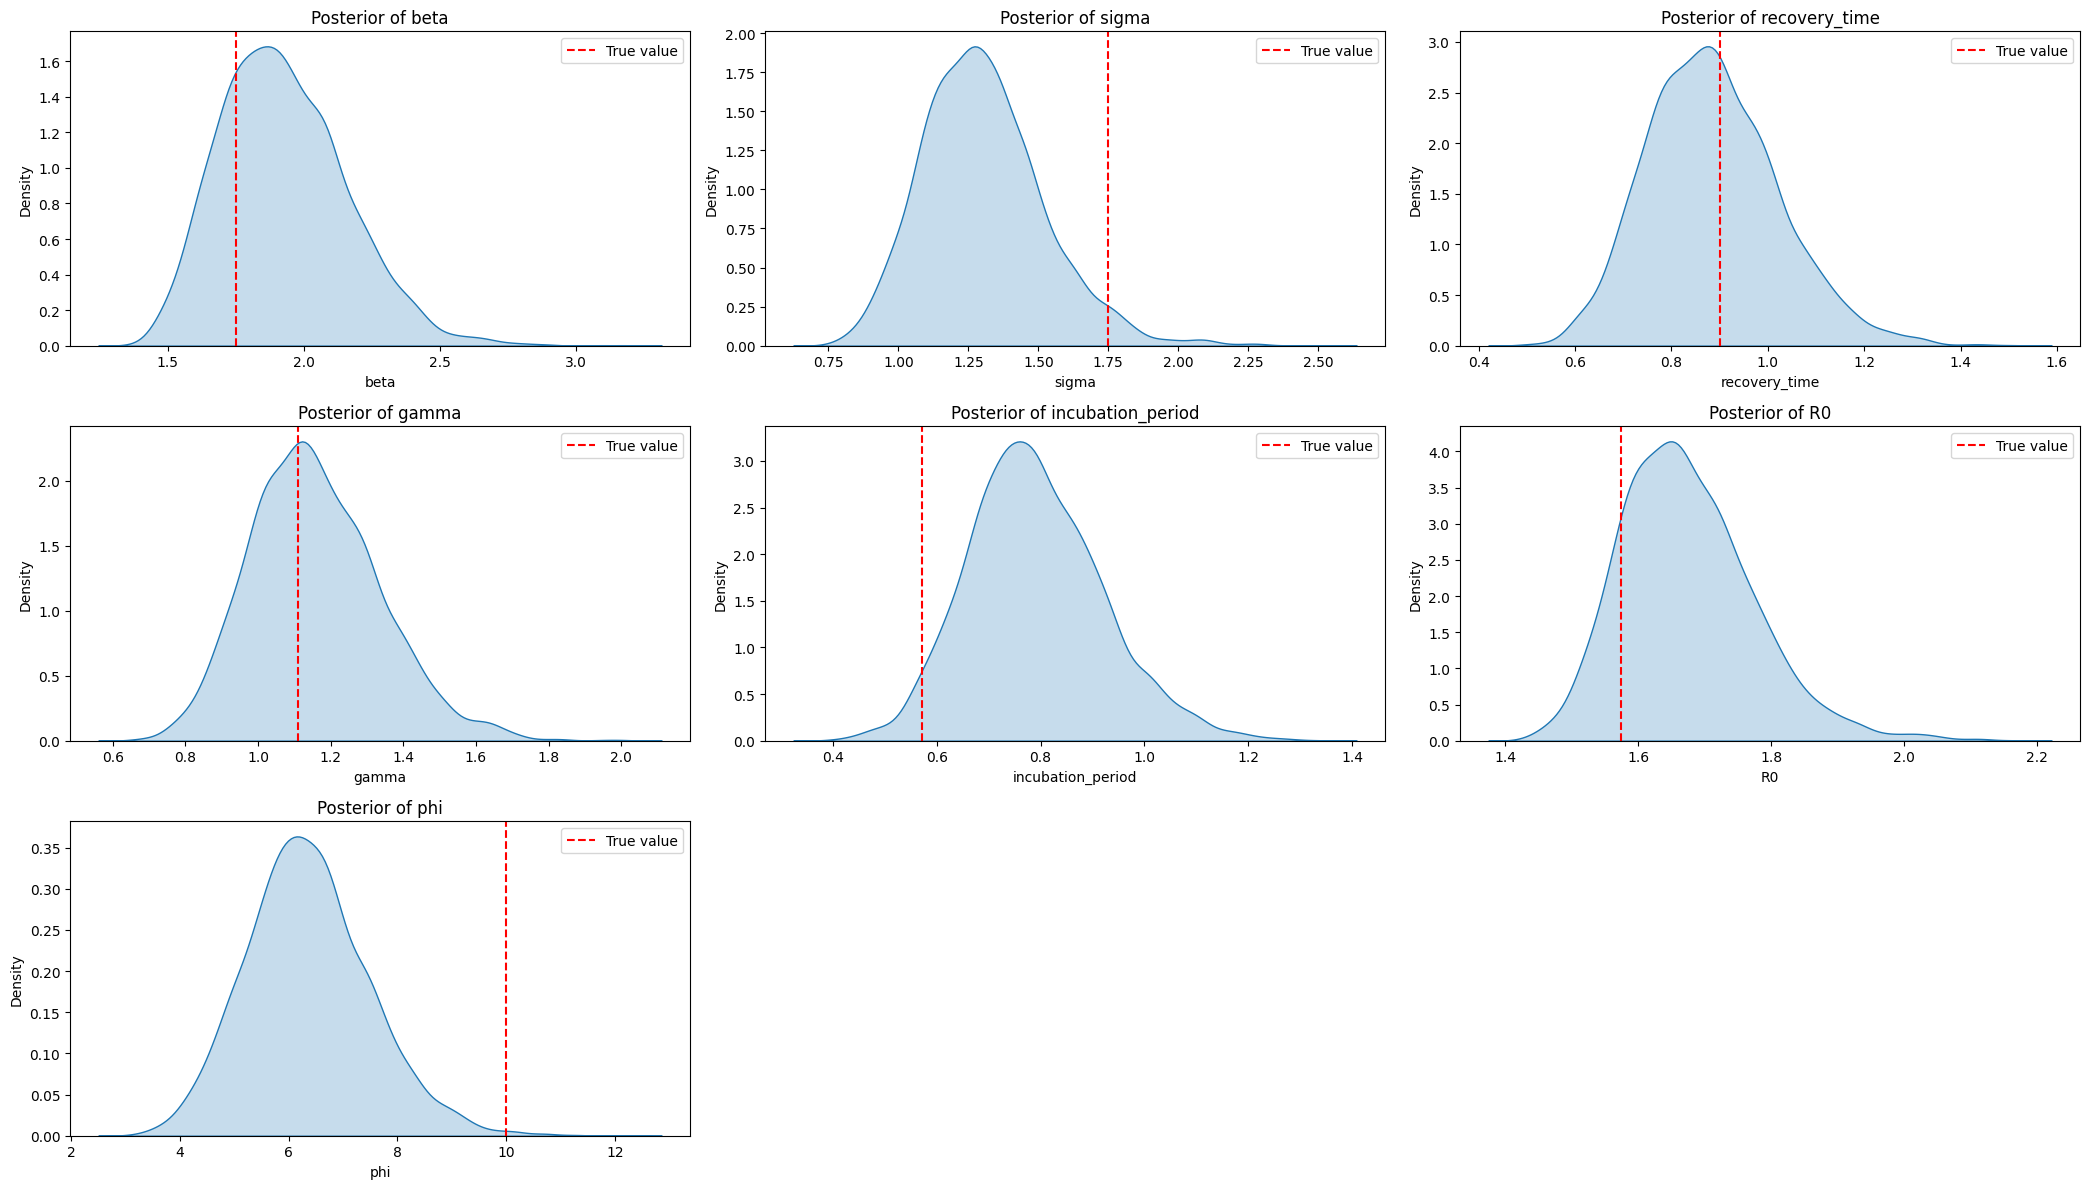

In [35]:
from posterior_plot import plot_posterior_kde_grid

plot_posterior_kde_grid(fit1, parameters1, 3,t1, save = 'Checks_for_Guinea')

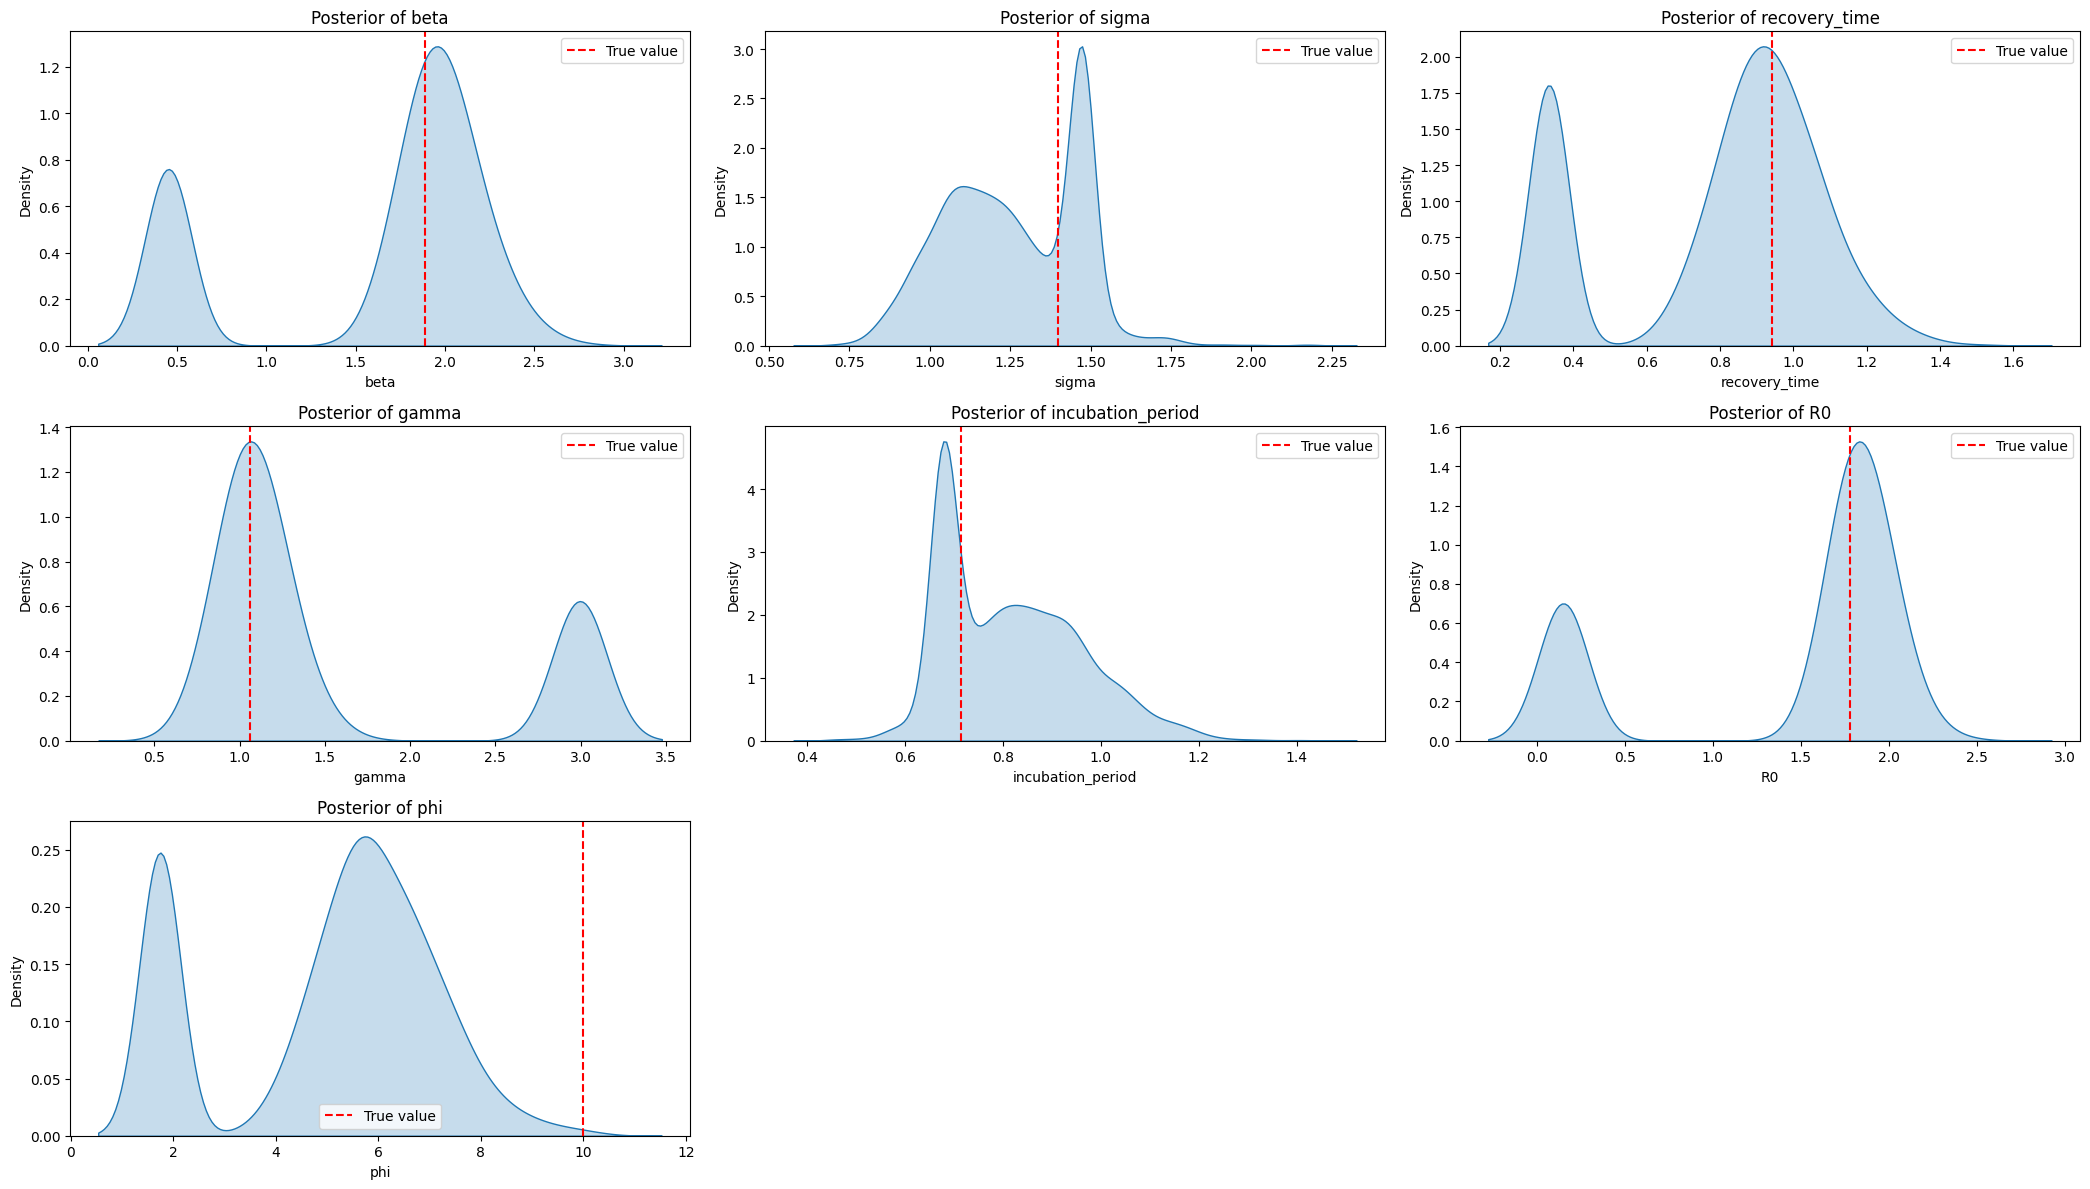

In [36]:
plot_posterior_kde_grid(fit2, parameters1, 3,t2, save = 'Checks_for_Liberia')

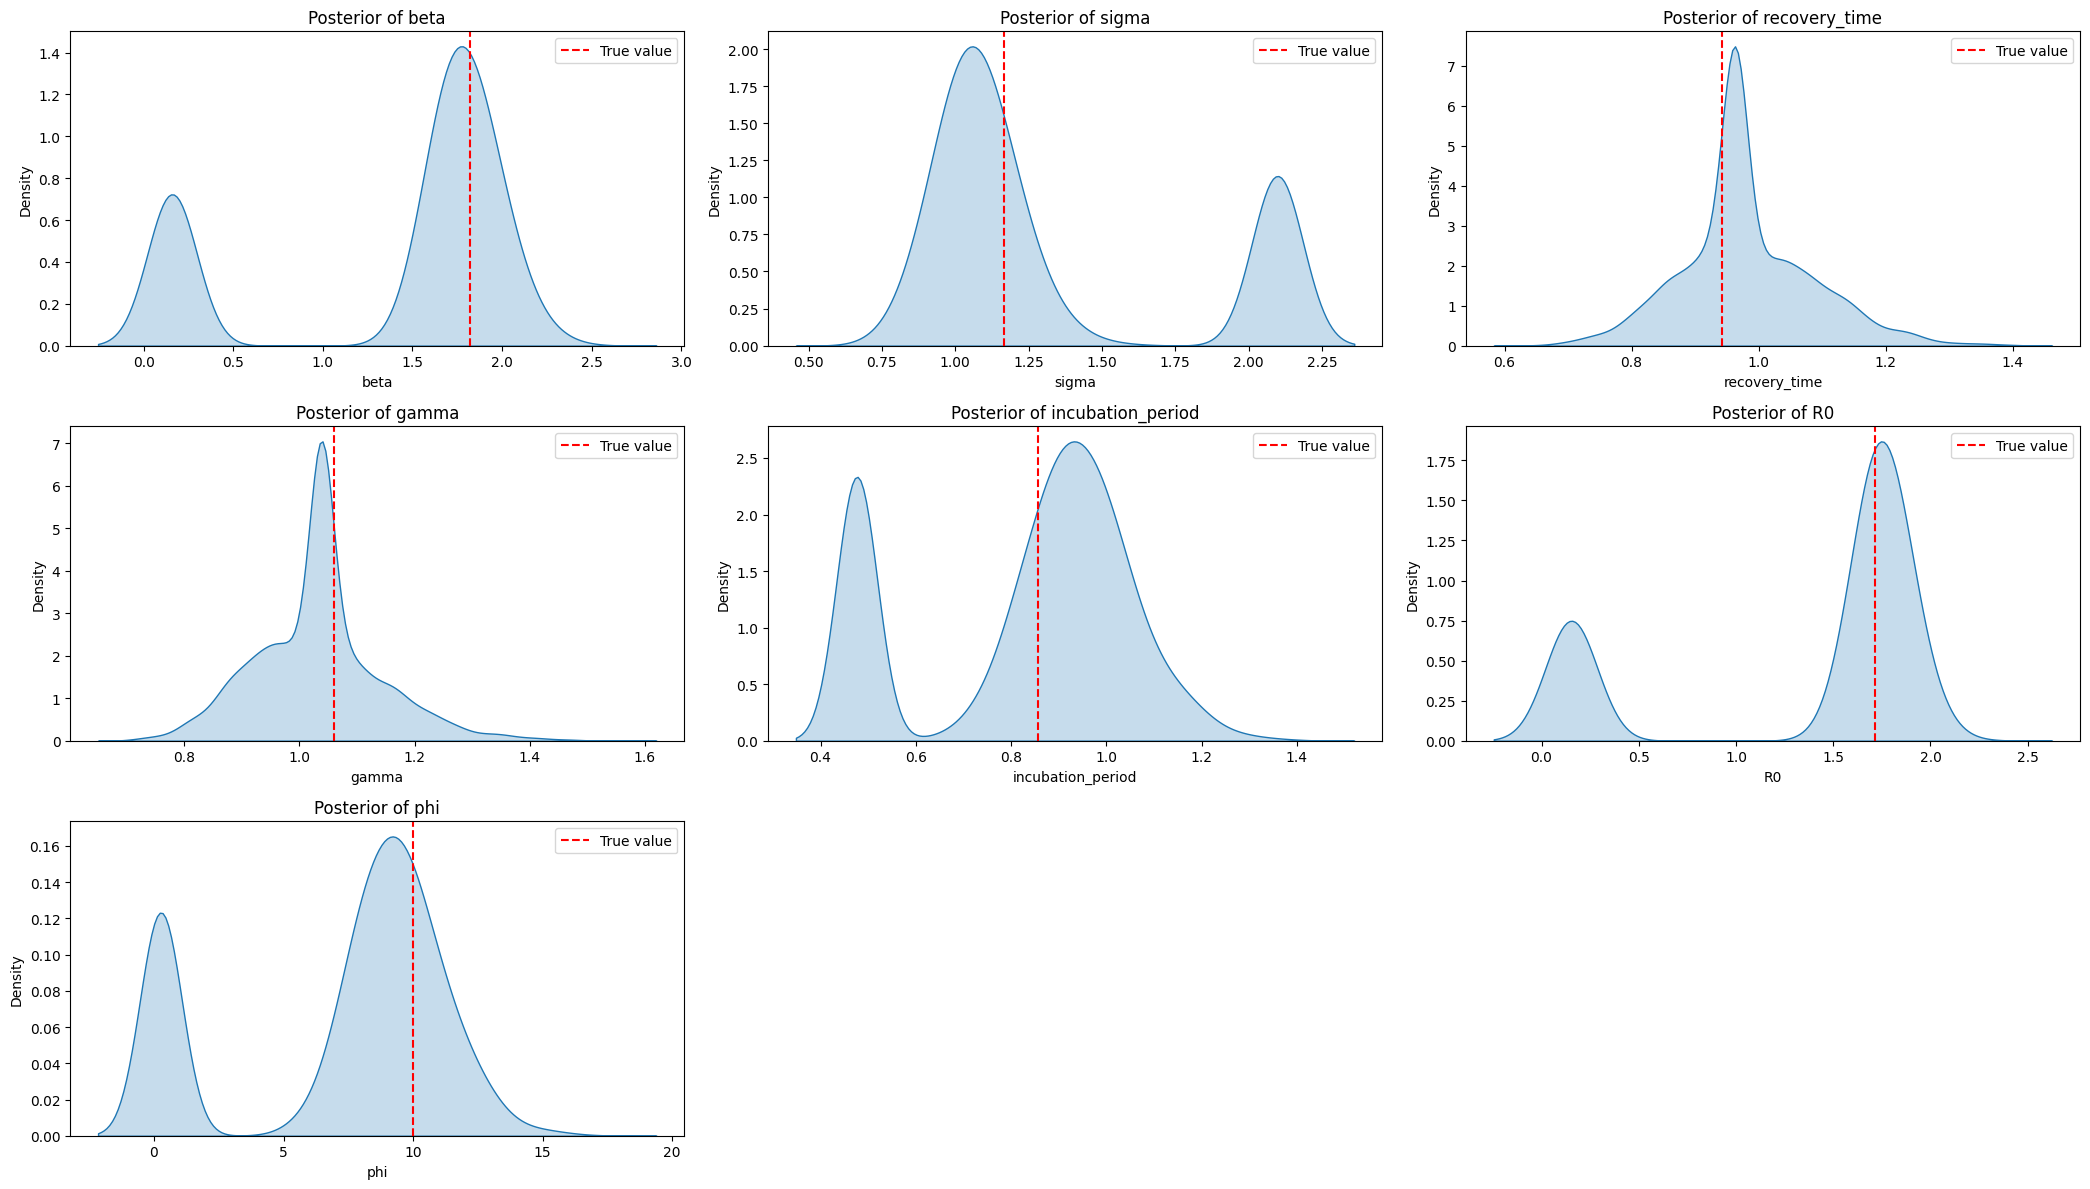

In [37]:
plot_posterior_kde_grid(fit3, parameters1, 3,t3, save = 'Checks_for_Sierra_Leone')

## Plot SEIR Compartments

In [38]:

def plot_compartment(fit, country_idx):
    # Time points and countries
    weeks = np.arange(fit.stan_variable('incidence').shape[1])  # Number of weeks
    countries = ['Guinea', 'Liberia', 'Sierra Leone']

    # Plot incidence (infectious) and reconstructed other compartments
    # for i in range(countries):
    # Create figure
    plt.figure(figsize=(12, 7))
    incidence = np.mean(fit.stan_variable('incidence'), axis=0)

    # Reconstruct approximate compartments (scaled by reporting rate)
    I = incidence
    R = np.cumsum(I) * np.mean(fit.stan_variable('gamma'))
    E = np.roll(I, 1) / np.mean(fit.stan_variable('sigma'))  # Exposed ~ delayed infectious
    # E[0] = 0
    S = N[country_idx] - E - I - R

    # Convert to fractions
    S_frac = S / N[country_idx]
    E_frac = E / N[country_idx]
    I_frac = I / N[country_idx]
    R_frac = R / N[country_idx]

    # Plot
    plt.plot(weeks, S_frac, 'b', label='Susceptible')
    plt.plot(weeks, E_frac, 'y', label='Exposed')
    plt.plot(weeks, I_frac, 'r', label='Infectious')
    plt.plot(weeks, R_frac, 'g', label='Recovered')

    # Formatting
    plt.title(f'{countries[country_idx]} (R0={np.mean(fit.stan_variable("R0")):.2f})')
    plt.ylabel('Fraction of Population')
    plt.grid(True, alpha=0.3)
    # ax.set_ylim(0, 1)

    plt.legend(loc='upper right')
    plt.xlabel('Weeks since outbreak start')
    # plt.tight_layout()
    plt.show()                                                                                      

In [39]:
# plot_compartment(fit1, country_idx=0)
# plot_compartment(fit2, country_idx=1)
# plot_compartment(fit3, country_idx=2)

# FITTING FOR 3 PATCHES

In [40]:
weekly = raw[['Guinea_Noise', 'Liberia_Noise', 'SierraLeone_Noise']]
weekly.head()

,Guinea_Noise,Liberia_Noise,SierraLeone_Noise
0,0,0,0
1,12,14,9
2,25,9,5
3,45,30,21
4,46,34,21


In [ ]:

N = np.array([11.5e6, 4.5e6, 6.8e6]) 

# Define initial conditions
g0 = [N[0]-10, 10, 10, 0, 0]
l0 = [N[1]-10, 10, 1, 0, 0]
s0 = [N[2]-10, 10, 1, 0, 0]

ts = weekly.values.T
y0 = [g0, l0, s0]

beta = np.array([0.25, 0.27, 0.26])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = np.array([1/4, 1/5, 1/6])*7 #incubation rate per week
gamma = np.array([1/6.3, 1/6.6, 1/6.6])*7  

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1  

# Make the data struture
seir_data = {
    'N_countries': 3,
    "n_weeks": len(ts[0]),
    'y0': y0,
    't0': 0,
    "t": np.arange(1, len(ts[0])+1),
    "N": N.astype(int),
    "cases": ts,
    'beta_values': beta,
    'sigma_values': sigma,
    'gamma_values': gamma,
    'reporting_rate': reporting_rate
}

multi_model = CmdStanModel(stan_file = 'stan files/mult.stan')

In [42]:
fit_multi_model = multi_model.sample(data = seir_data,
                                     iter_sampling = 1000,
                                    #  parallel_chains=True,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status


chain 1 |▍         | 01:10 Status
chain 1 |▉         | 06:35 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 14:36 Iteration:  100 / 2000 [  5%]  (Warmup)

chain 1 |█▊        | 24:10 Iteration:  200 / 2000 [ 10%]  (Warmup)



KeyboardInterrupt: 

In [ ]:
print(fit_multi_model.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [ ]:
multy_fit_summary = fit_multi_model.summary()
multy_fit_summary.filter(items=("beta[1]","beta[2]", "beta[3]", 
                               "sigma", "gamma", "recovery_time", 
                                "R0[1]","R0[2]", "R0[3]", 
                               "incubation_period", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
beta[1],1.885630,0.004056,0.250185,0.246771,1.526210,1.855620,2.332290,4148.72,2508.59,1.00024
beta[2],2.576200,0.003592,0.225291,0.212983,2.242040,2.556660,2.976690,4241.10,3084.23,1.00392
beta[3],2.223900,0.004070,0.247477,0.239195,1.874870,2.197870,2.669390,4078.88,2577.14,1.00219
R0[1],2.689930,0.006674,0.432196,0.415002,2.088880,2.633940,3.469550,4347.45,3106.04,1.00053
R0[2],3.169770,0.006522,0.431935,0.410428,2.552460,3.131120,3.940630,4620.08,2900.41,1.00035
R0[3],2.347150,0.004116,0.283593,0.277884,1.944400,2.314890,2.861190,4879.20,2645.88,1.00203
phi,6.234070,0.013313,0.959251,0.951125,4.760100,6.185530,7.918790,5360.60,3023.43,1.00083
phi_inv,0.164252,0.000356,0.025544,0.024791,0.126282,0.161668,0.210079,5360.40,3023.43,1.00064


In [ ]:
# # Extract posterior samples
# post_no = fit_multi_model.draws_pd()

# ## save the posterior samples
# post_no.to_csv('./Data/posterior_samples_no_coupling.csv', index=False)

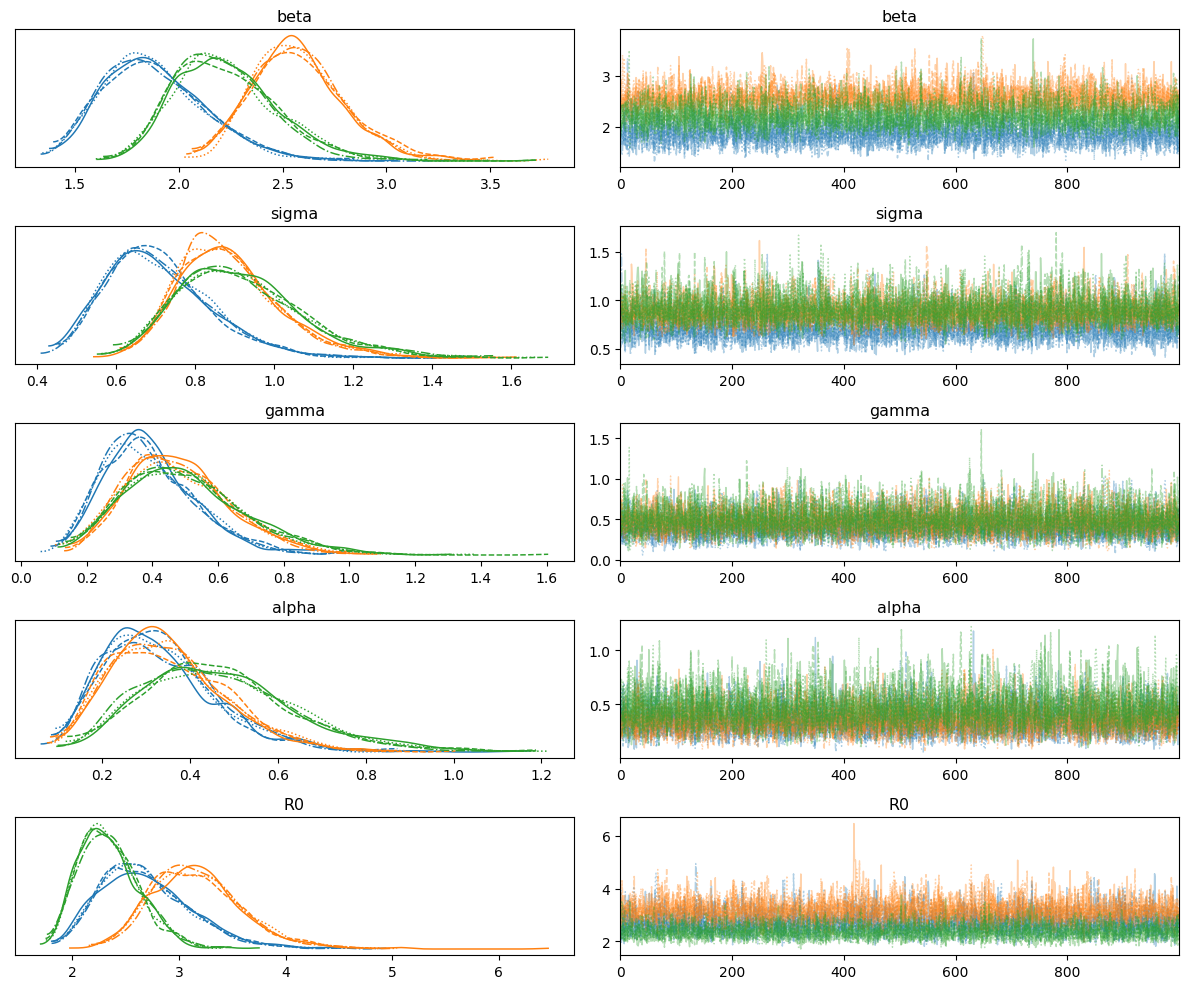

In [ ]:

az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

# POSTERIOR PREDICTIVE CHECK

In [ ]:
# Get available variables
# Assuming `fit` is your CmdStanMCMC object from fitting the model
posterior_samples = fit_multi_model.draws_pd()  # returns a pandas DataFrame

beta = np.array([0.25, 0.27, 0.26])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = np.array([1/4, 1/5, 1/6])*7 #incubation rate per week
gamma = np.array([1/6.3, 1/6.6, 1/6.6])*7    # 1/infectious period (Ebola: ~7 days)

phi = 10            # Negative binomial dispersion parameter
reporting_rate = 1
r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

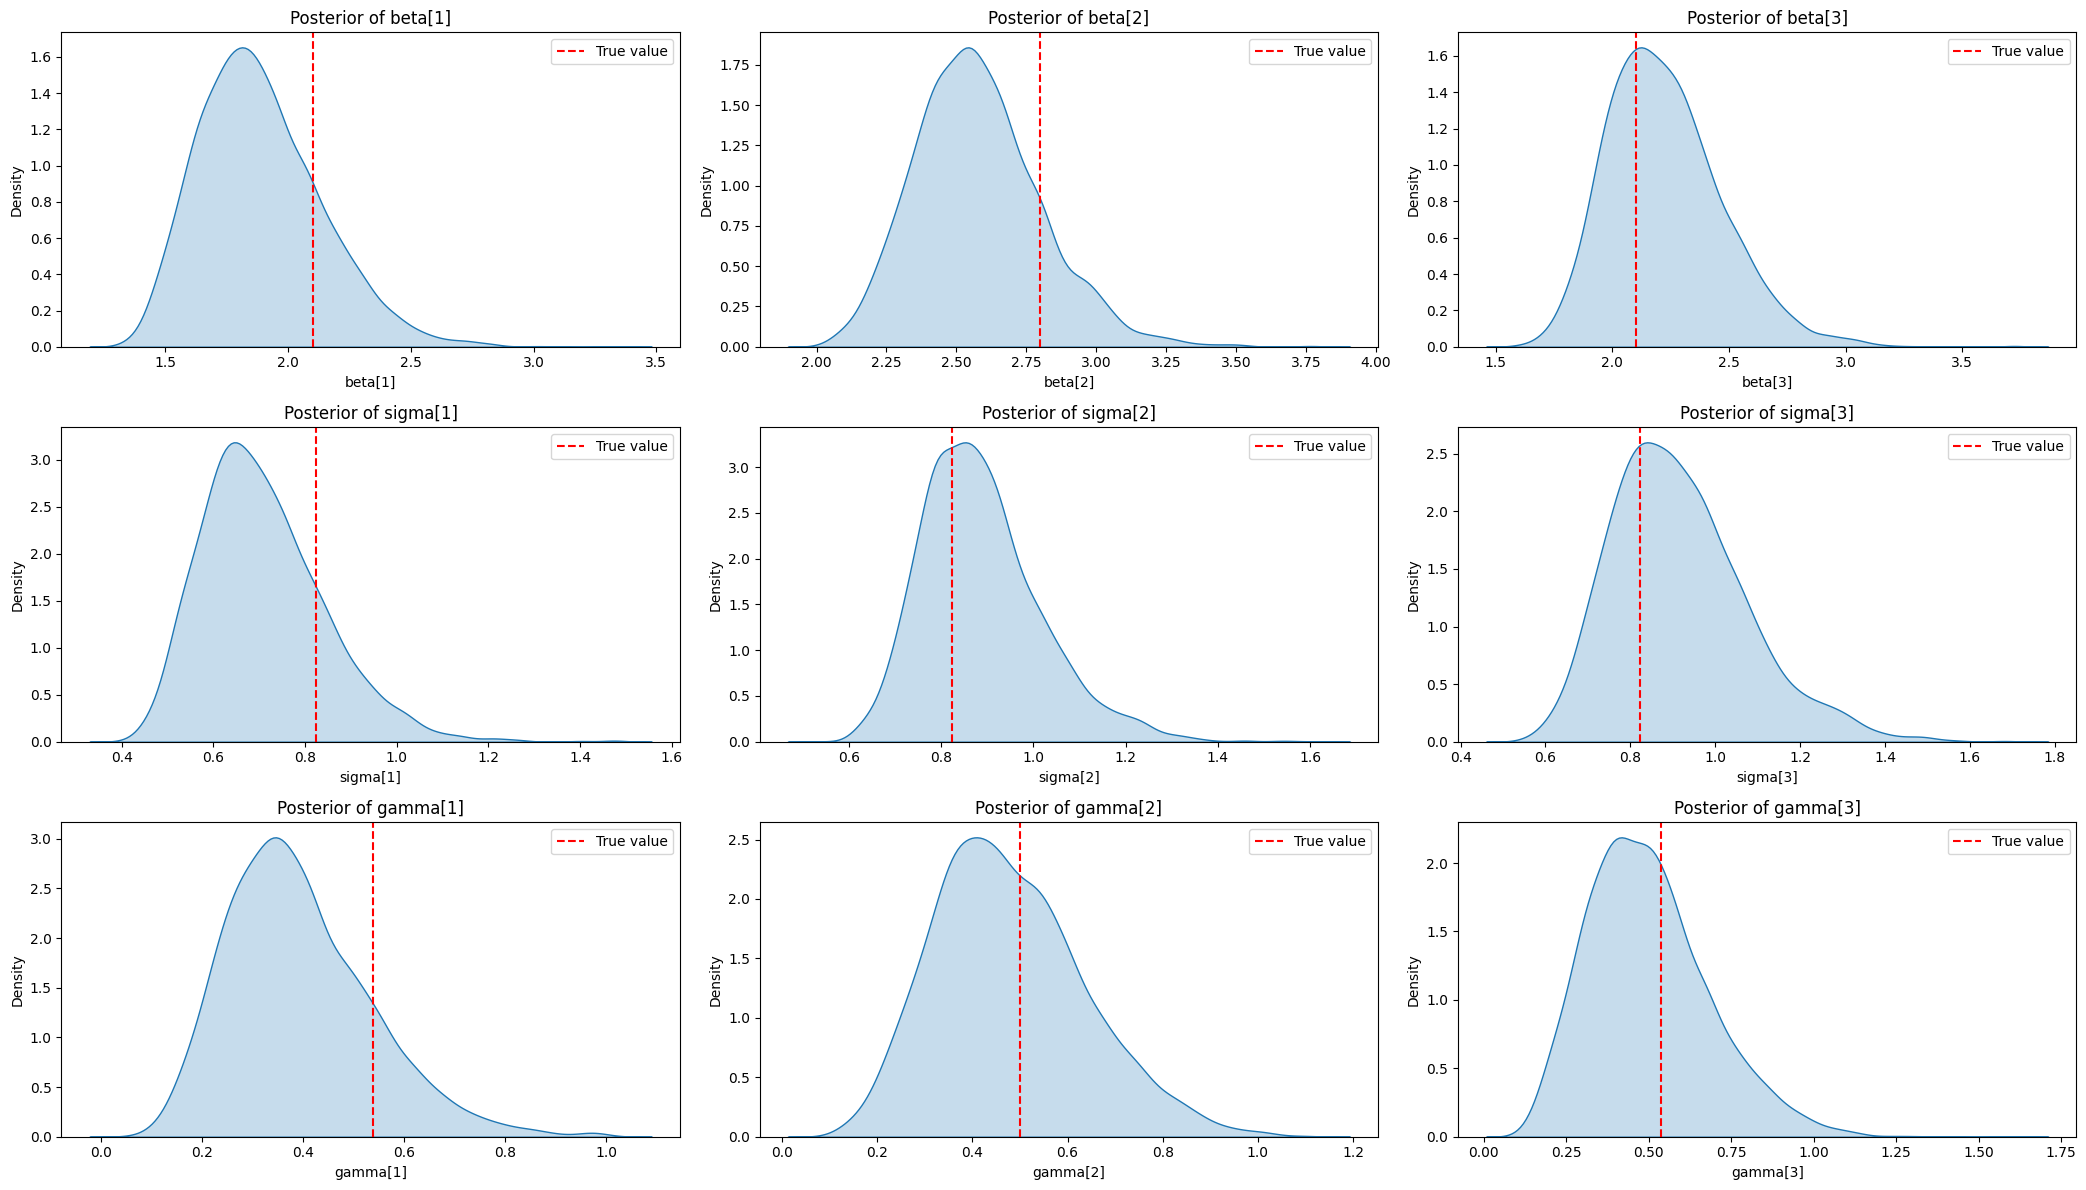

In [ ]:
parameters = ["beta[1]","beta[2]", "beta[3]", 
                "sigma[1]","sigma[2]","sigma[3]", 
                "gamma[1]","gamma[2]","gamma[3]"]
                
t = {'beta[1]': beta[0], 'beta[2]': beta[1], 'beta[3]': beta[2],
    'sigma[1]': sigma[0], 'sigma[2]': sigma[1], 'sigma[3]': sigma[2],   
    'gamma[1]': gamma[0], 'gamma[2]': gamma[1], 'gamma[3]': gamma[2],
    'phi': phi , 'reporting_rate':1}

plot_posterior_kde_grid(fit_multi_model, parameters=parameters, n_cols=3, true_values=t, save = 'Checks_for_betaGammaSigma')

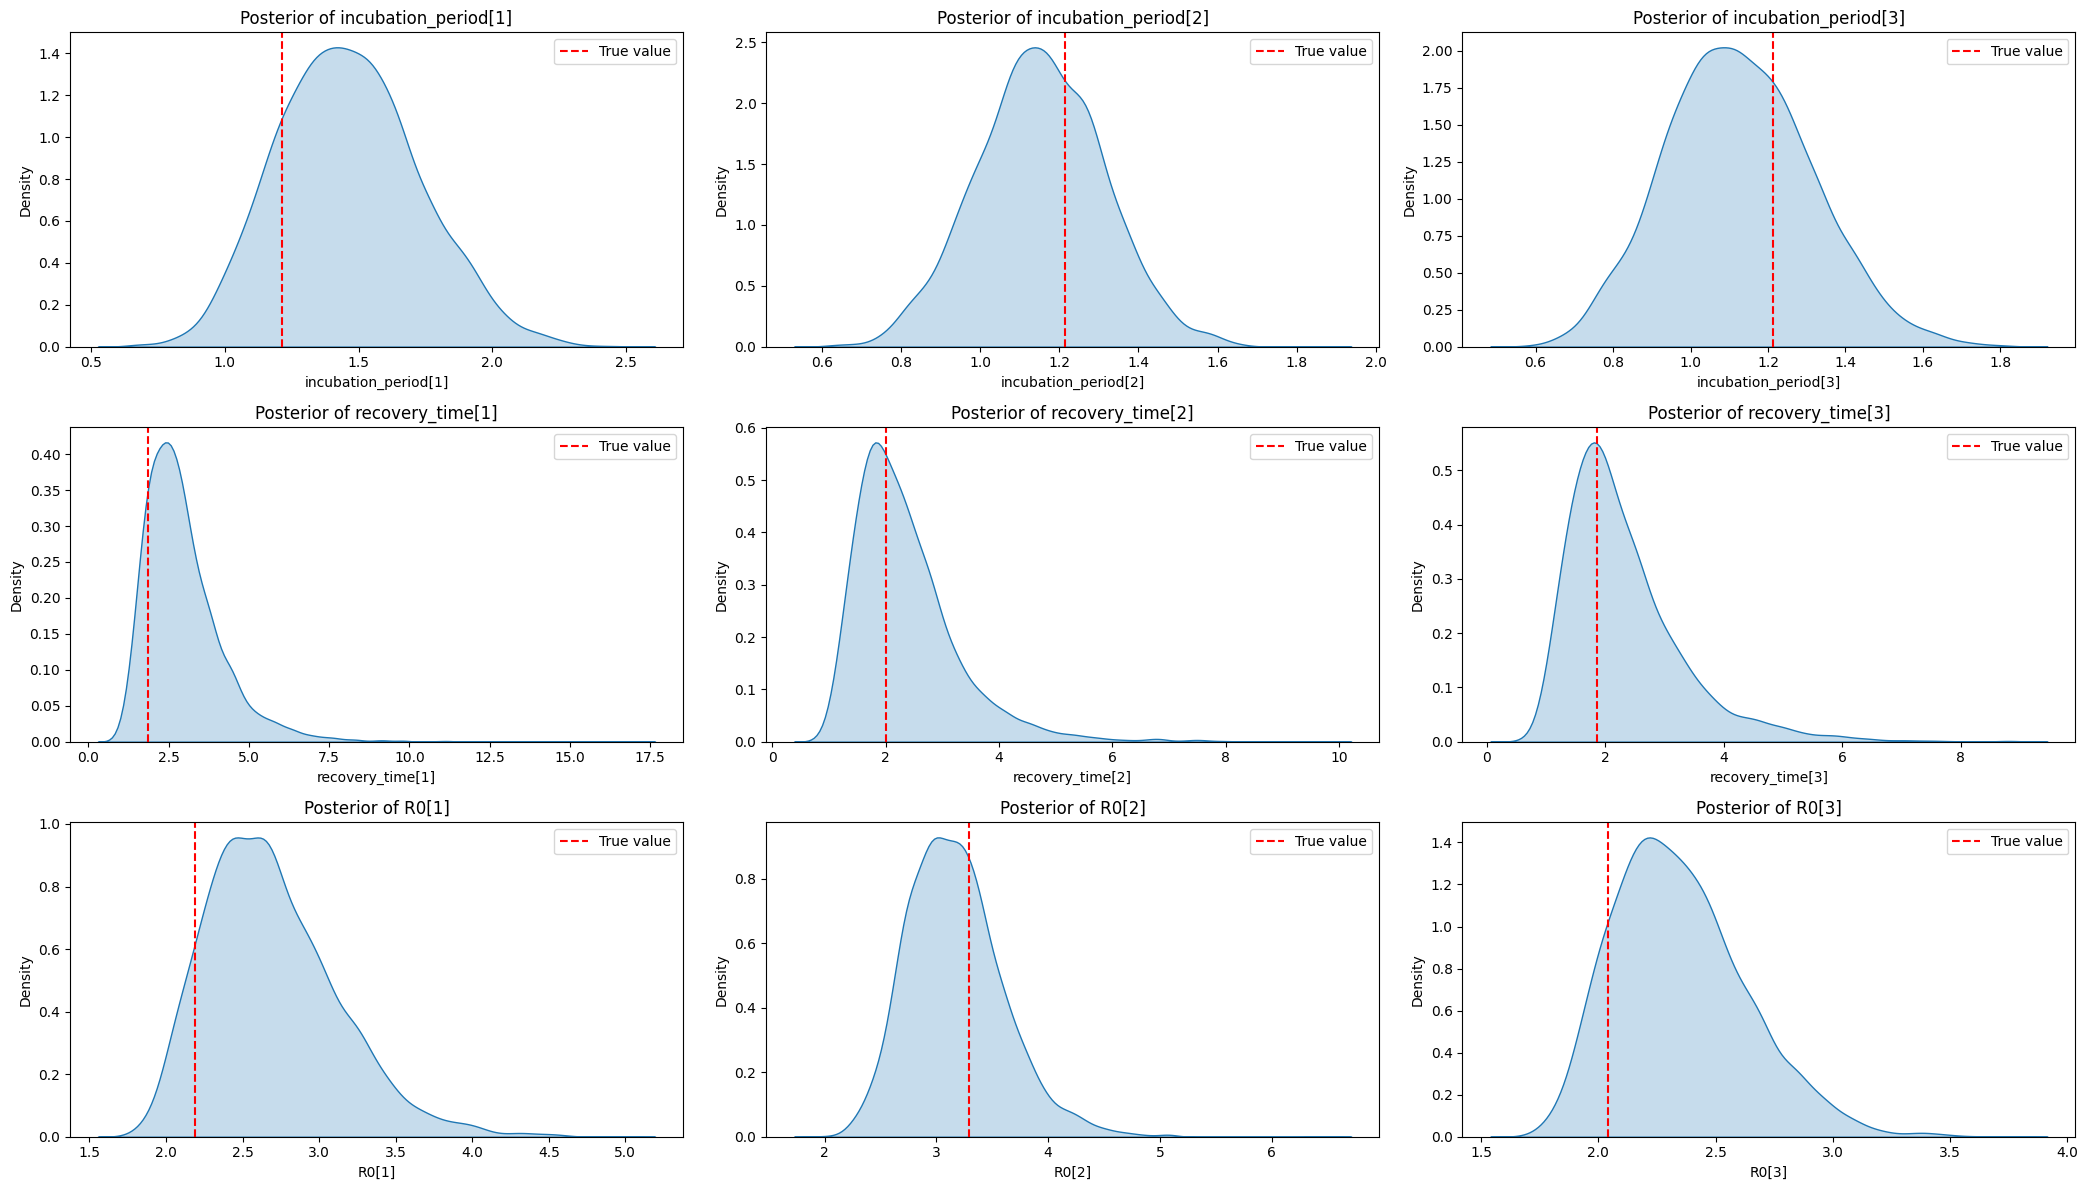

In [ ]:
parameters1 = ["incubation_period[1]","incubation_period[2]","incubation_period[3]", 
                "recovery_time[1]","recovery_time[2]","recovery_time[3]",
                "R0[1]","R0[2]", "R0[3]"]
t1 = {
    'R0[1]': r[0], 'R0[2]': r[1], 'R0[3]': r[2], 
    'recovery_time[1]':rec[0],
    'recovery_time[2]':rec[1],
    'recovery_time[3]':rec[2],
    'incubation_period[1]': incu[0],
    'incubation_period[2]': incu[1],
    'incubation_period[3]': incu[2]}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1, save = 'Checks_for_recoveryIncubationR0')

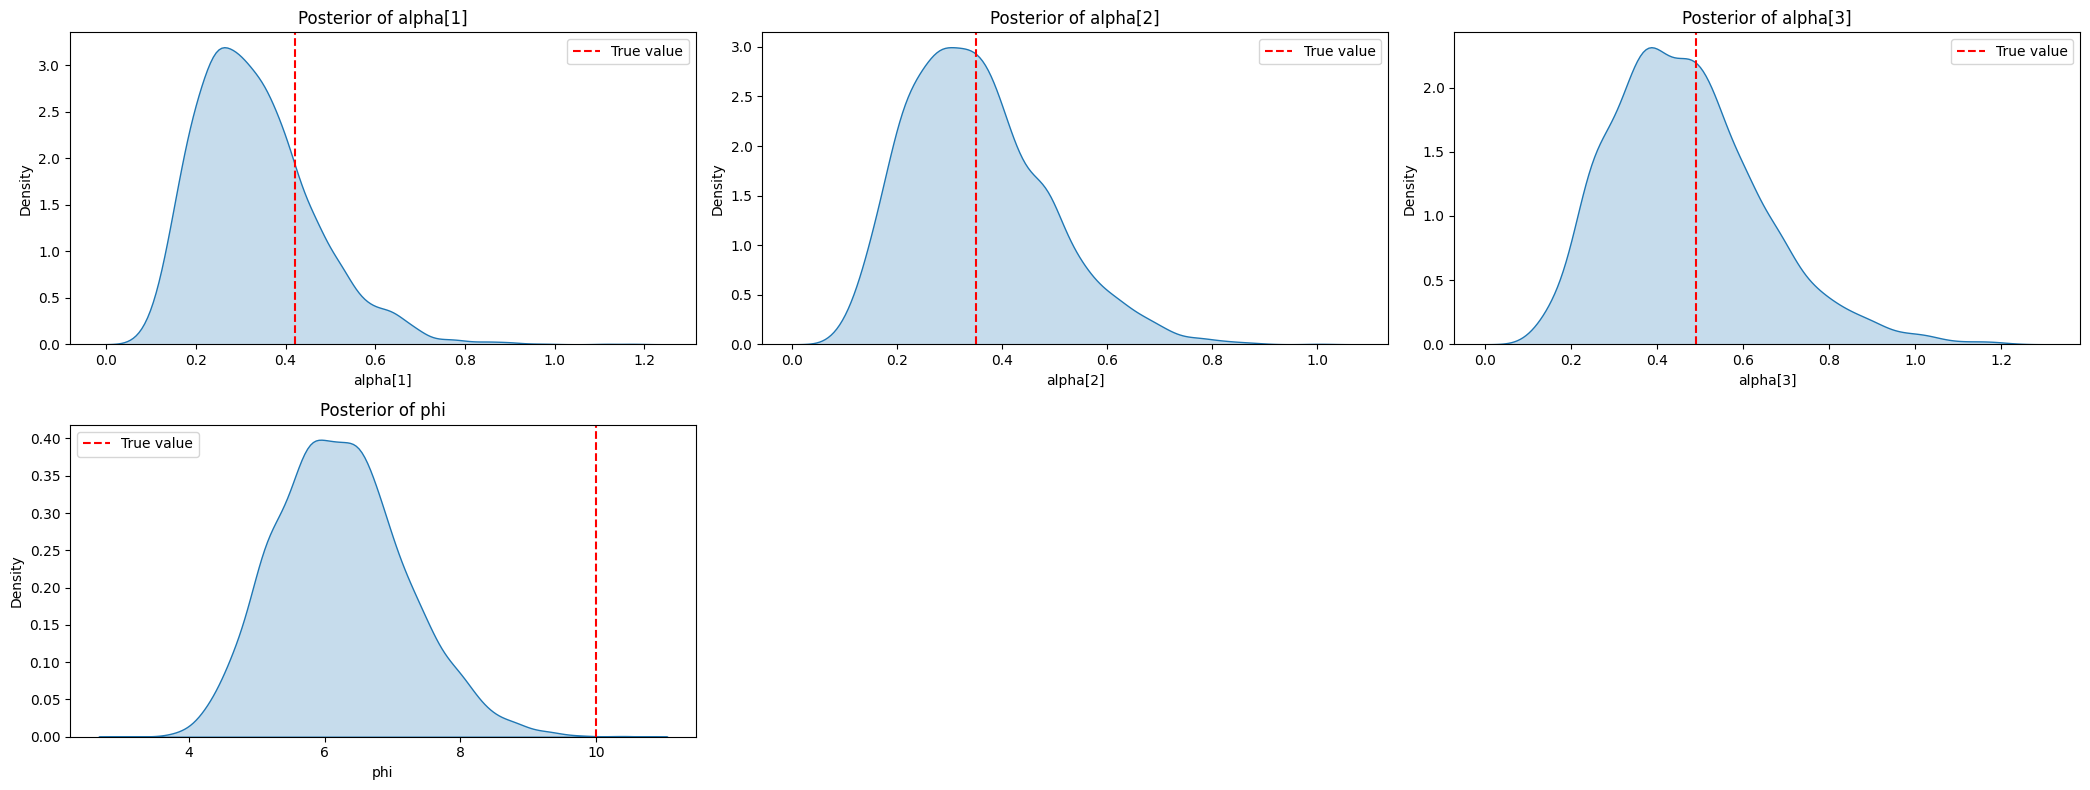

In [ ]:
parameters1 = ['phi']
t1 = {'phi': phi}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1, save = 'Checks_for_alphaPhi')

# PRIOR PREDICTIVE CHECK

In [ ]:

model_prior = CmdStanModel(stan_file = 'stan files/multi_patch_PRIOR.stan')
prior_check = model_prior.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status


chain 1 |▉         | 00:18 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 01:41 Iteration:  100 / 2000 [  5%]  (Warmup)

chain 1 |█▊        | 02:10 Iteration:  200 / 2000 [ 10%]  (Warmup)
chain 1 |██▎       | 02:14 Iteration:  300 / 2000 [ 15%]  (Warmup)




















chain 1 |██▋       | 08:19 Iteration:  400 / 2000 [ 20%]  (Warmup)

chain 1 |███▏      | 08:22 Iteration:  500 / 2000 [ 25%]  (Warmup)

chain 1 |███▋      | 08:27 Iteration:  600 / 2000 [ 30%]  (Warmup)

chain 1 |████      | 08:42 Iteration:  700 / 2000 [ 35%]  (Warmup)

chain 1 |████▌     | 08:44 Iteration:  800 / 2000 [ 40%]  (Warmup)

chain 1 |█████▍    | 08:56 Iteration: 1000 / 2000 [ 50%]  (Warmup)

chain 1 |████████▏ | 09:34 Iteration: 1500 / 2000 [ 75%]  (Sampling)

chain 1 |████████▋ | 09:40 Iteration: 1600 / 2000 [ 80%]  (Sampling)

chain 1 |█████████ | 09:55 Iteration: 1700 / 2000 [ 85%]  (Sampling)

chain 1 |█████████▌| 09:58 Iteration: 1800 / 2000 [ 90%

In [ ]:
import math
def plot_prior(model, param_names, boundary, ncols=3, 
               figsize_per_plot=(8, 7), 
               sharey=True, 
               legend_on_first=True):
    

    countries = ['Guinea','Liberia','Sierra Leone']
    n_params = len(param_names)
    nrows   = math.ceil(n_params / ncols)
    fig_w   = figsize_per_plot[0] * ncols
    fig_h   = figsize_per_plot[1] * nrows+1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
    
    # flatten even if nrows or ncols == 1
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, pname) in enumerate(zip(axes, param_names)):
        # pull samples: shape (n_samples, n_patches)
        samples = model.stan_variable(pname)
        df = pd.DataFrame(samples, columns=countries)
        
        # plot densities
        df.plot(kind='density', ax=ax, legend=False)
        ax.set_title(f'Prior predictive check for {pname}')
        ax.set_xlabel(pname)
        ax.grid(True)
        ax.axvline(x=boundary[i*2], color='r')
        ax.axvline(x=boundary[i*2+1], color='r')
    
    # hide any unused axes
    for ax in axes[n_params:]:
        ax.set_visible(False)

    
    # add legend if desired
    if legend_on_first and n_params > 0:
        axes[0].legend(countries, title='Patch')
    
    plt.tight_layout()
    return fig, axes


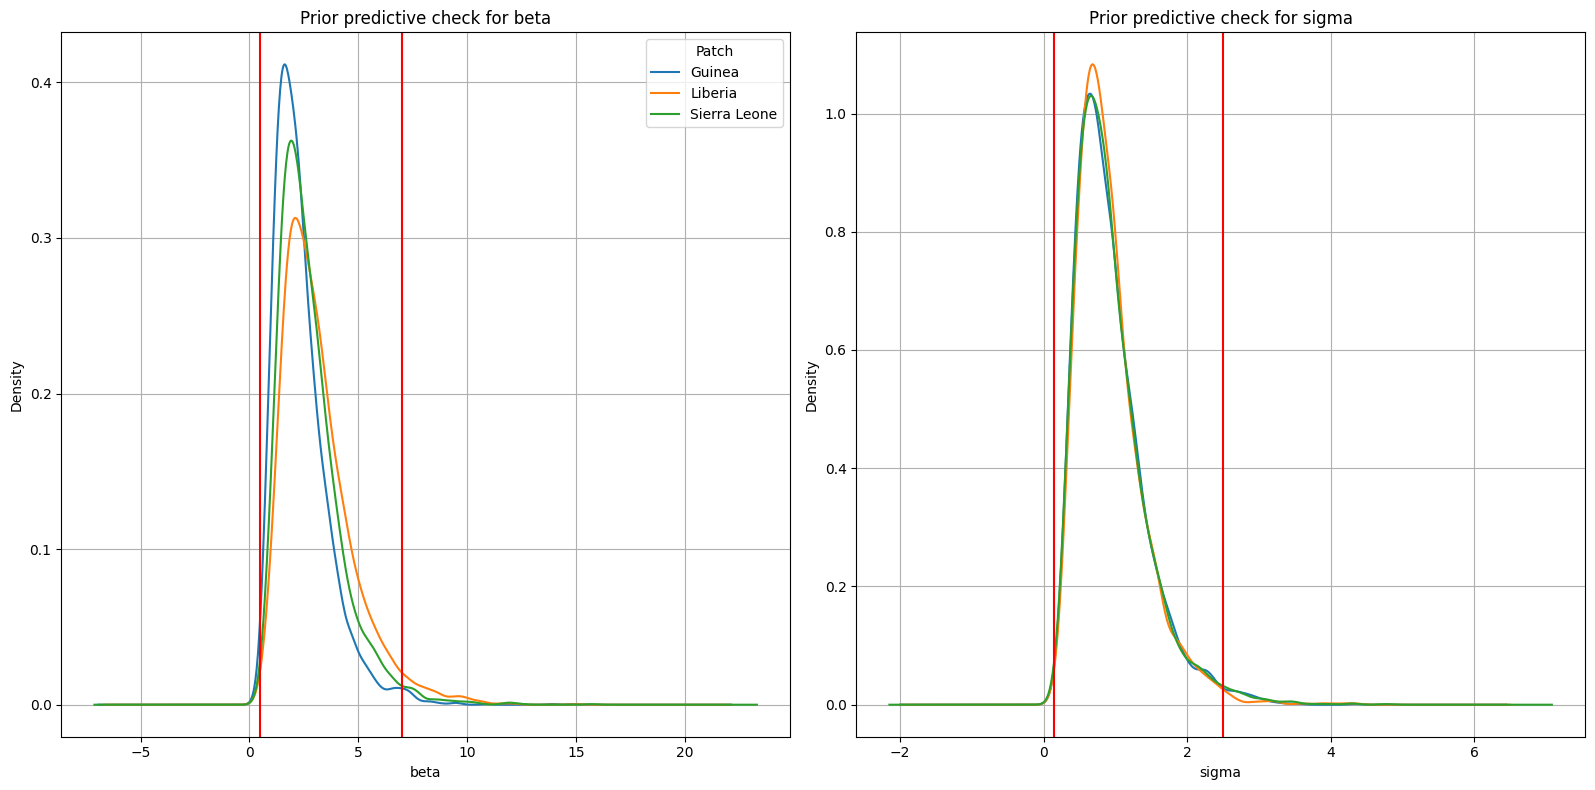

In [ ]:
params = ['beta','sigma', 'gamma']
boundaries = [0.5, 7, 0.14, 2.5, 0.1, 2.0]

# 5 parameters → grid of 2×3 (since ncols=3)
fig, axes = plot_prior(prior_check, params, boundary = boundaries, ncols=3)
plt.show()

In [ ]:
# infection_draws = prior_check.draws_pd("y")
# lines = plt.plot(range(1,15),
#                  infection_draws,
#                  color = "k", alpha = 0.1)
# plt.axhline(y=N[0], color='r', linestyle='--')
# plt.xlabel('Time')
# plt.ylabel('Number of infections')
# plt.show()

# R0

from sympy import *
init_printing()